# Can Unsupervised Learning Discover Clinically Meaningful Thyroid Cancer Patient Subgroups?

## Introduction

The objective of this notebook is to investigate whether thyroid cancer patients naturally form clinically meaningful subgroups using unsupervised learning techniques. Unlike supervised learning, where models learn from labeled outcomes, clustering algorithms identify hidden structures within the data without access to recurrence information. This allows us to explore whether patients with similar clinicopathologic characteristics naturally group together.

### Research Question

> Can clustering algorithms identify clinically meaningful subgroups of thyroid cancer patients using clinicopathologic characteristics without access to recurrence information?

### Datasets: Two preprocessed feature sets will be investigated.

- Feature Set A: Baseline clinicopathologic characteristics.
- Feature Set B: Baseline clinicopathologic characteristics together with treatment response.

> The resulting cluster structures will be compared to evaluate the influence of post-treatment information on patient subgroup discovery.

### - Import Libraries

In [2]:
# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"

# Data handling & Visualization
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
from utils import *

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Evaluation metics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, \
    adjusted_rand_score, normalized_mutual_info_score, silhouette_samples

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



### - Load datasets

In [3]:
X_A = pd.read_csv(DATA_DIR / "feature_set_A.csv")
X_B = pd.read_csv(DATA_DIR / "feature_set_B.csv")

# External validation only
y = pd.read_csv(DATA_DIR / "recurred.csv")

In [4]:
X_A.head(5)

,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,...,nom__Adenopathy_Right,nom__Pathology_Follicular,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage
0,-0.923305,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
1,-0.460609,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
2,-0.725007,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
3,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
4,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0


In [5]:
X_B.head(5)

,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,...,nom__Pathology_Follicular,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage,ord__Response
0,-0.923305,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0
1,-0.460609,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
2,-0.725007,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
3,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
4,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0


### 1) Determine the Optimal Number of Clusters

This section investigates whether the dataset itself suggests a more appropriate number of clusters. Several internal evaluation techniques are employed to identify an optimal value of K, The selected K will later be used as the optimal K in the algorithms.

In [4]:
def find_best_k(
    X,
    model_class,
    k_range=range(2,11),
    random_state=42,
    **kwargs
):

    results = []

    best_model = None
    best_score = -1
    best_k = None

    for k in k_range:

        # Build model
        if model_class.__name__ == "GaussianMixture":

            model = model_class(
                n_components=k,
                random_state=random_state,
                **kwargs
            )

        else:
            if model_class.__name__ == "AgglomerativeClustering":
                model = model_class(
                    n_clusters=k,
                    **kwargs
                )
            else:
                model = model_class(
                    n_clusters=k,
                    random_state=random_state,
                    **kwargs
                )

        # Fit
        labels = model.fit_predict(X)

        # Metrics
        silhouette = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)

        # Inertia only exists for KMeans
        inertia = getattr(model, "inertia_", np.nan)

        results.append({
            "K": k,
            "Silhouette": silhouette,
            "Calinski-Harabasz": ch,
            "Davies-Bouldin": db,
            "Inertia": inertia
        })

        if silhouette > best_score:

            best_score = silhouette
            best_k = k
            best_model = model

    results_df = pd.DataFrame(results)

    return best_k, best_model, results_df



In [5]:
def apply_find_best_k(X_A, X_B):

    clustering_models = {
        "KMeans": KMeans,
        "AgglomerativeClustering": AgglomerativeClustering,
        "GaussianMixture": GaussianMixture
    }

    optimal_results = {}

    for name, model in clustering_models.items():

        # Feature Set A
        best_k_A, best_model_A, results_A = find_best_k(
            X_A,
            model
        )

        optimal_results[f"{name}_A"] = {
            "Best K": best_k_A,
            "Best Model": best_model_A,
            "Results": results_A
        }

        # Feature Set B
        best_k_B, best_model_B, results_B = find_best_k(
            X_B,
            model
        )

        optimal_results[f"{name}_B"] = {
            "Best K": best_k_B,
            "Best Model": best_model_B,
            "Results": results_B
        }

    return optimal_results

opt_rsls = apply_find_best_k(X_A, X_B)

In [6]:
opt_rsls_df = pd.concat(
    [
        value["Results"].assign(
            Algorithm=key.split("_")[0],
            Feature_Set=key.split("_")[1]
        )
        for key, value in opt_rsls.items()
    ],
    ignore_index=True
)

# Optional: nicer column order
opt_rsls_df = opt_rsls_df[
    [
        "Algorithm",
        "Feature_Set",
        "K",
        "Silhouette",
        "Calinski-Harabasz",
        "Davies-Bouldin",
        "Inertia"
    ]
]

opt_rsls_df

,Algorithm,Feature_Set,K,Silhouette,Calinski-Harabasz,Davies-Bouldin,Inertia
0,KMeans,A,2,0.311612,137.325636,1.505742,2110.412701
1,KMeans,A,3,0.193692,101.711580,1.498592,1868.761840
2,KMeans,A,4,0.228144,104.124182,1.483040,1571.526264
3,KMeans,A,5,0.227163,91.362390,1.626530,1457.112654
4,KMeans,A,6,0.197663,86.514630,1.696374,1334.090164
5,KMeans,A,7,0.197241,79.503112,1.613436,1262.518367
6,KMeans,A,8,0.171314,73.071278,1.690885,1211.418619
7,KMeans,A,9,0.170578,66.231952,1.813751,1184.884614
8,KMeans,A,10,0.175135,61.616186,1.710313,1151.411850
9,KMeans,B,2,0.317972,146.898677,1.466397,2302.822543


In [7]:
def optimal_k_summary(optimal_results):

    rows = []

    for key, value in optimal_results.items():

        algorithm, feature_set = key.split("_")

        rows.append({
            "Algorithm": algorithm,
            "Feature Set": feature_set,
            "Best K": value["Best K"]
        })

    return pd.DataFrame(rows)

optimal_k_summary(opt_rsls)

,Algorithm,Feature Set,Best K
0,KMeans,A,2
1,KMeans,B,2
2,AgglomerativeClustering,A,2
3,AgglomerativeClustering,B,2
4,GaussianMixture,A,2
5,GaussianMixture,B,2


In [8]:
def plot_best_k_metrics(opt_rsls, algorithm, feature_set):

    key = f"{algorithm}_{feature_set}"
    df = opt_rsls[key]["Results"]

    if algorithm == "KMeans":

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # Elbow
        axes[0,0].plot(df["K"], df["Inertia"], marker="o", color="#ff2313")
        axes[0,0].set_title("Elbow Curve")
        axes[0,0].set_xlabel("Number of Clusters (K)")
        axes[0,0].set_ylabel("Inertia")
        axes[0,0].grid(alpha=0.3)

        # Silhouette
        axes[0,1].plot(df["K"], df["Silhouette"], marker="o", color="#009ee7")
        best = df["Silhouette"].idxmax()
        axes[0,1].scatter(df.loc[best,"K"],
                          df.loc[best,"Silhouette"],
                          color="red", s=90)
        axes[0,1].set_title("Silhouette Score")
        axes[0,1].set_xlabel("Number of Clusters (K)")
        axes[0,1].grid(alpha=0.3)

        # CH
        axes[1,0].plot(df["K"], df["Calinski-Harabasz"], marker="o", color="#009ee7")
        best = df["Calinski-Harabasz"].idxmax()
        axes[1,0].scatter(df.loc[best,"K"],
                          df.loc[best,"Calinski-Harabasz"],
                          color="red", s=90)
        axes[1,0].set_title("Calinski-Harabasz")
        axes[1,0].set_xlabel("Number of Clusters (K)")
        axes[1,0].grid(alpha=0.3)

        # DB
        axes[1,1].plot(df["K"], df["Davies-Bouldin"], marker="o", color="#009ee7")
        best = df["Davies-Bouldin"].idxmin()
        axes[1,1].scatter(df.loc[best,"K"],
                          df.loc[best,"Davies-Bouldin"],
                          color="red", s=90)
        axes[1,1].set_title("Davies-Bouldin")
        axes[1,1].set_xlabel("Number of Clusters (K)")
        axes[1,1].grid(alpha=0.3)

    else:

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Silhouette
        axes[0].plot(df["K"], df["Silhouette"], marker="o", color="#009ee7")
        best = df["Silhouette"].idxmax()
        axes[0].scatter(df.loc[best,"K"],
                        df.loc[best,"Silhouette"],
                        color="red", s=90)
        axes[0].set_title("Silhouette Score")
        axes[0].set_xlabel("Number of Clusters (K)")
        axes[0].grid(alpha=0.3)

        # CH
        axes[1].plot(df["K"], df["Calinski-Harabasz"], marker="o", color="#009ee7")
        best = df["Calinski-Harabasz"].idxmax()
        axes[1].scatter(df.loc[best,"K"],
                        df.loc[best,"Calinski-Harabasz"],
                        color="red", s=90)
        axes[1].set_title("Calinski-Harabasz")
        axes[1].set_xlabel("Number of Clusters (K)")
        axes[1].grid(alpha=0.3)

        # DB
        axes[2].plot(df["K"], df["Davies-Bouldin"], marker="o", color="#009ee7")
        best = df["Davies-Bouldin"].idxmin()
        axes[2].scatter(df.loc[best,"K"],
                        df.loc[best,"Davies-Bouldin"],
                        color="red", s=90)
        axes[2].set_title("Davies-Bouldin")
        axes[2].set_xlabel("Number of Clusters (K)")
        axes[2].grid(alpha=0.3)

    fig.suptitle(f"{algorithm} - Feature Set {feature_set}", fontsize=15)
    plt.tight_layout()
    plt.show()


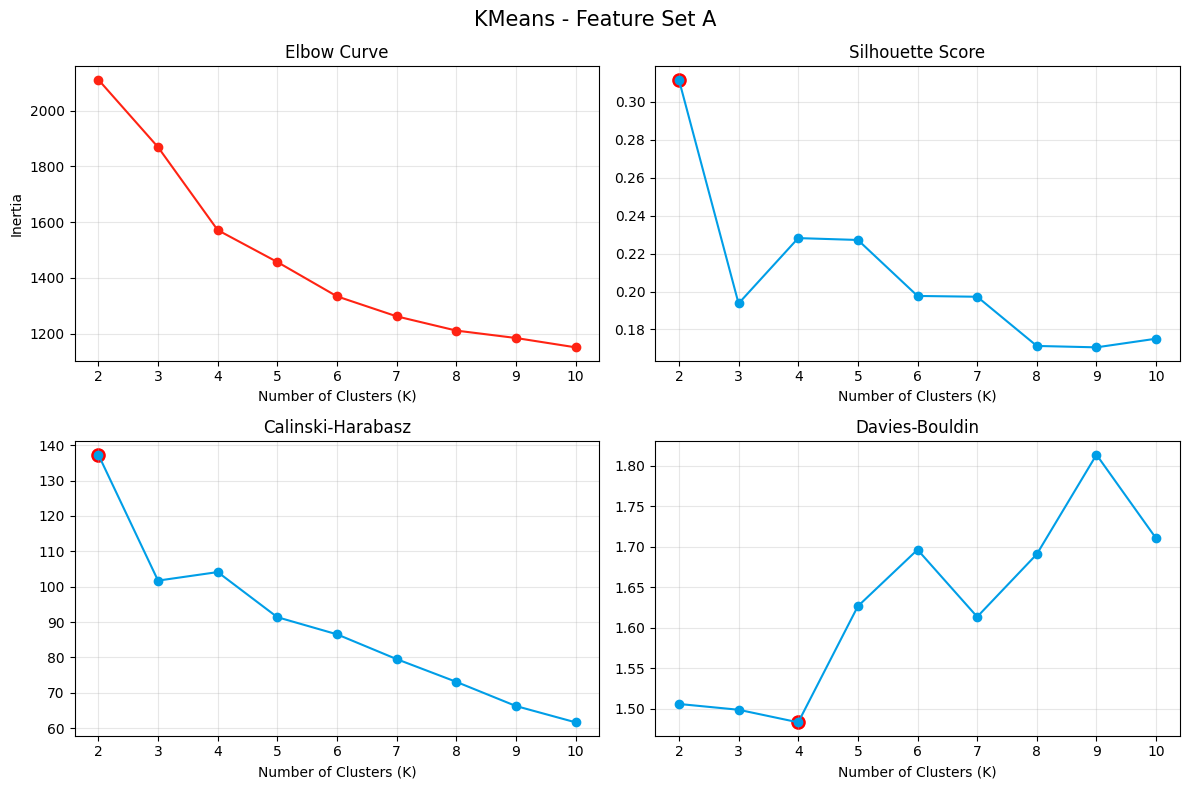

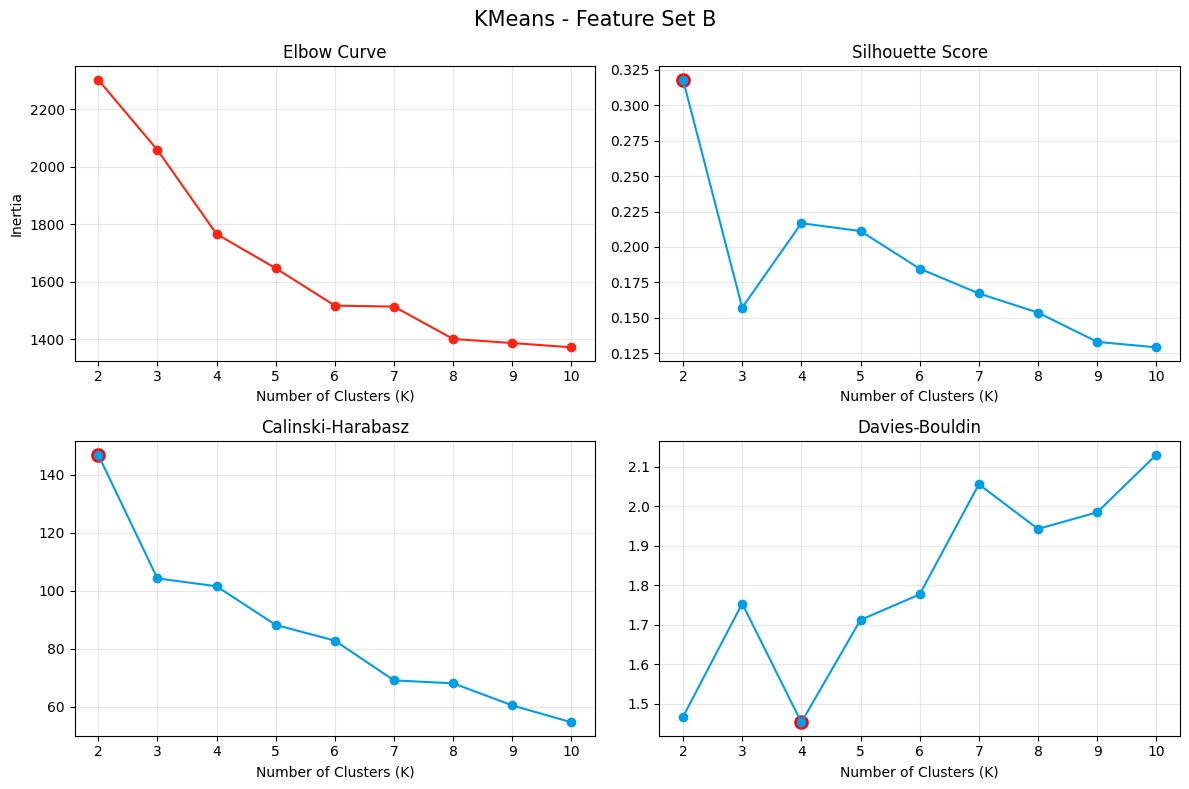

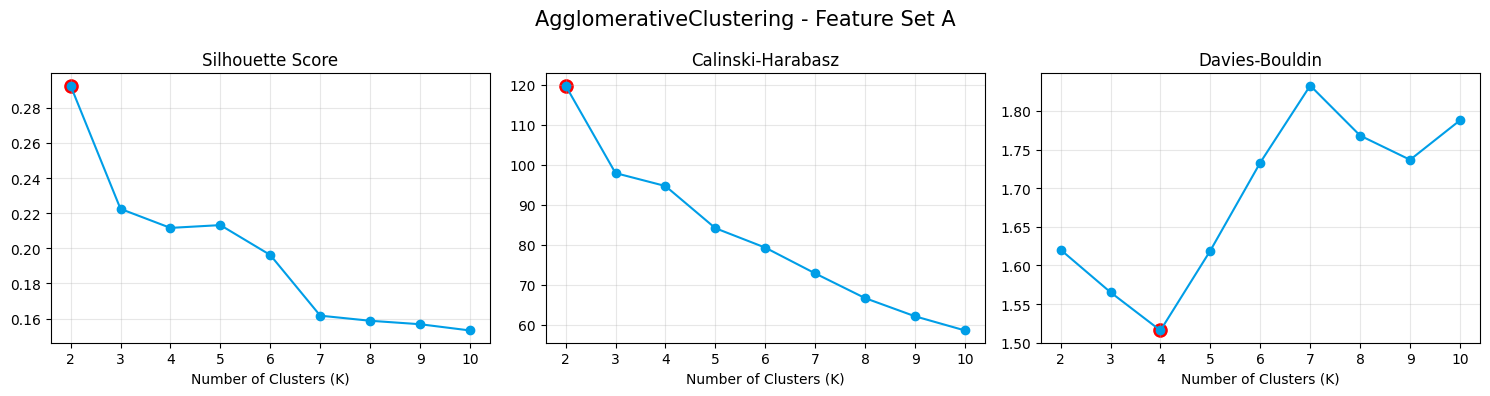

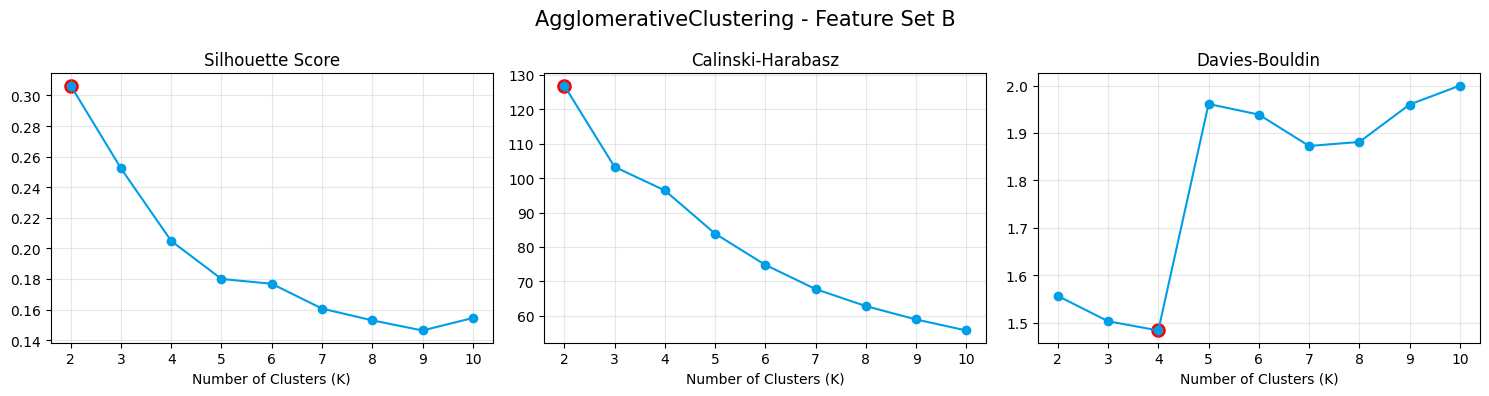

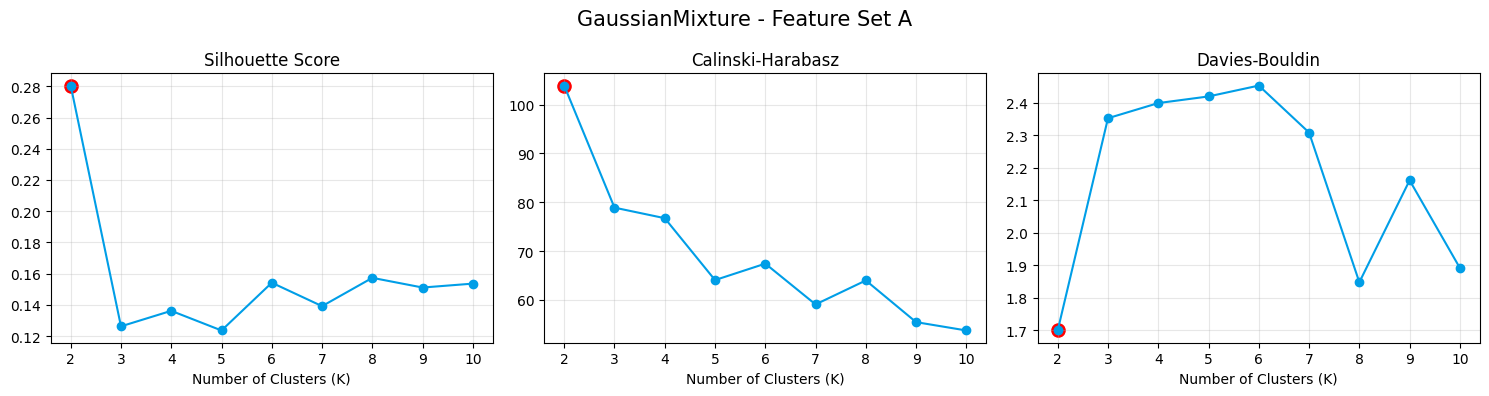

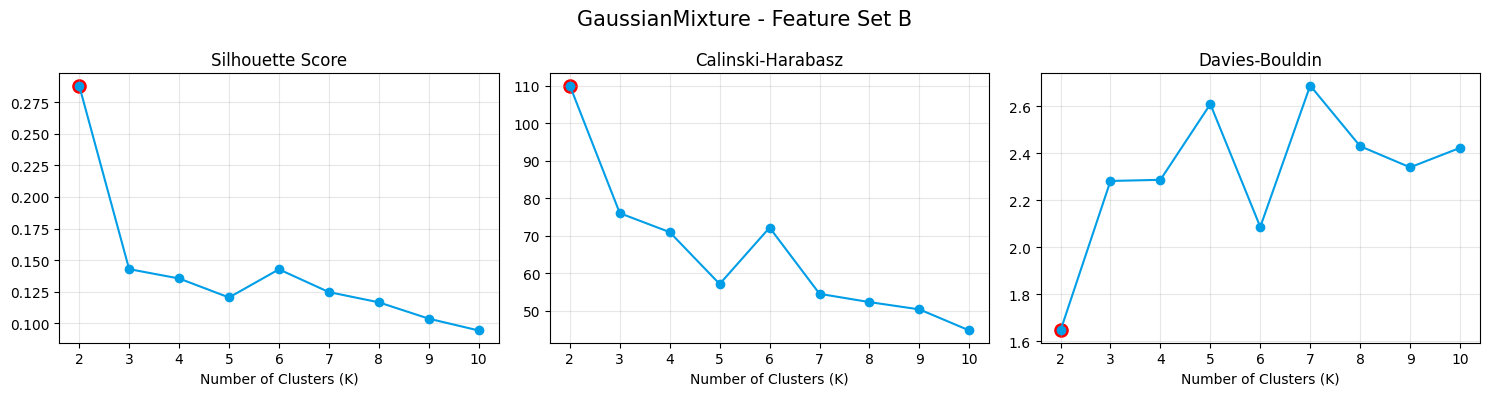

In [9]:
plot_best_k_metrics(opt_rsls, "KMeans", "A")
plot_best_k_metrics(opt_rsls, "KMeans", "B")

plot_best_k_metrics(opt_rsls, "AgglomerativeClustering", "A")
plot_best_k_metrics(opt_rsls, "AgglomerativeClustering", "B")

plot_best_k_metrics(opt_rsls, "GaussianMixture", "A")
plot_best_k_metrics(opt_rsls, "GaussianMixture", "B")

> Cluster selection is based on multiple complementary criteria rather than a single metric. While the elbow method suggested an elbow around K≈4, the Silhouette Score, Calinski–Harabasz Index, and the automated optimization procedure consistently identified K=2 as the optimal solution. Therefore, K=2 was selected for the subsequent clustering analysis due to its stronger overall quantitative support and simpler interpretation.

In [10]:
# The most optimal K
K = 2

### 2) Fit the algorithms on sets and predict (Manual clustring)

In [11]:
def clustering_algorithms(X, n_clusters=K, eps=1.5, min_samples=5, n_components=K, RANDOM_STATE=42):
    # A dict of clustring algorithms
    clustering_algo = {
        "KMeans": KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE),
        "DBSCAN": DBSCAN(eps=eps, min_samples=min_samples),
        "AgglomerativeClustering": AgglomerativeClustering(n_clusters=n_clusters),
        "GaussianMixture": GaussianMixture(n_components=n_components, random_state=RANDOM_STATE)
    }

    # Fit, Predict and Store the Results
    algo_clusters = {f'{name} Clusters': algo.fit_predict(X) for name, algo in clustering_algo.items()}
    
    return algo_clusters, clustering_algo


In [12]:
# Apply models on the sets
X_A_clusters, clt_algo = clustering_algorithms(X_A)
X_B_clusters, clt_algo = clustering_algorithms(X_B)

### 2) Internal Evaluation

In [13]:
def internal_evaluation(X, clusters):
    # Calculate internal evaluation metrics
    silhouette = silhouette_score(X, clusters)
    db = davies_bouldin_score(X, clusters)
    ch = calinski_harabasz_score(X, clusters)

    return silhouette, db, ch


In [14]:
def evaluation_results(clt_algo, X_A_clusters, X_B_clusters):
    # A list to store results
    results = []
    
    for name in clt_algo.keys():

        clusters = f"{name} Clusters"

        # Feature Set A
        s, db, ch = internal_evaluation(X_A, X_A_clusters[clusters])

        results.append({
            "Algorithm": name,
            "Feature Set": "A",
            "Silhouette": s,
            "Davies-Bouldin": db,
            "Calinski-Harabasz": ch
        })

        # Feature Set B
        s, db, ch = internal_evaluation(X_B, X_B_clusters[clusters])

        results.append({
            "Algorithm": name,
            "Feature Set": "B",
            "Silhouette": s,
            "Davies-Bouldin": db,
            "Calinski-Harabasz": ch
        })

    return pd.DataFrame(results)


evaluation_df = evaluation_results(
    clt_algo,
    X_A_clusters,
    X_B_clusters
)

evaluation_df


,Algorithm,Feature Set,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,A,0.311612,1.505742,137.325636
1,KMeans,B,0.317972,1.466397,146.898677
2,DBSCAN,A,0.138710,2.421144,52.336145
3,DBSCAN,B,0.071328,2.108087,32.895007
4,AgglomerativeClustering,A,0.292604,1.620362,119.812667
5,AgglomerativeClustering,B,0.306432,1.556580,126.827090
6,GaussianMixture,A,0.280469,1.699078,103.903917
7,GaussianMixture,B,0.288087,1.645164,110.072756


#### - Plot Manual Internal Evaluation

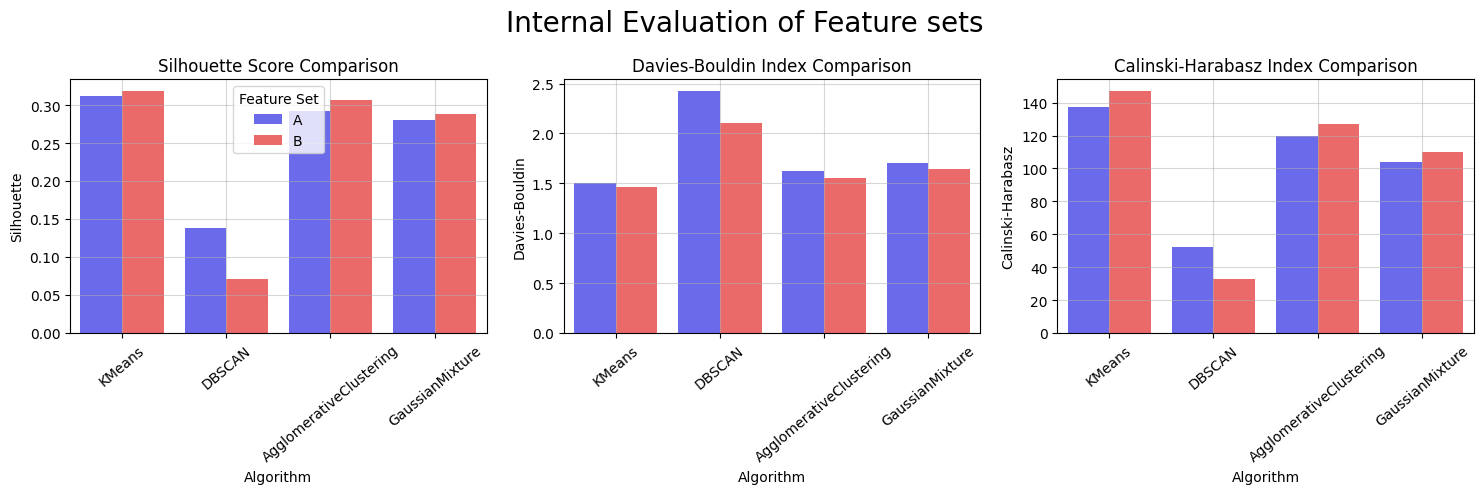

In [15]:
# ----------------------------------------------------
# Clustering Evaluation Metrics Comparison - Bar Plot
# ----------------------------------------------------

def bar_plot_eval_results(evaluation_df, metrics, titles):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, metric, title in zip(axes, metrics, titles):
        sns.barplot(
            data=evaluation_df,
            x="Algorithm",
            y=metric,
            hue="Feature Set",
            palette="seismic",
            ax=ax
        )

        ax.set_title(title)
        ax.grid(alpha=0.5)
        ax.tick_params(axis='x', rotation=40)

    # Show legend only once
    handles, labels = axes[0].get_legend_handles_labels()

    for ax in axes[1:]:
        ax.get_legend().remove()

    axes[0].legend(title="Feature Set")

    plt.suptitle("Internal Evaluation of Feature sets", fontsize=20)
    plt.tight_layout()
    plt.show()


metrics = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz"
]

titles = [
    "Silhouette Score Comparison",
    "Davies-Bouldin Index Comparison",
    "Calinski-Harabasz Index Comparison"
]

bar_plot_eval_results(evaluation_df, metrics, titles)

In [17]:
def plot_silhouette_analysis(
    X_A,
    X_B,
    X_A_clusters,
    X_B_clusters,
    algorithm
):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    feature_sets = [
        ("A", X_A, X_A_clusters),
        ("B", X_B, X_B_clusters)
    ]

    for ax, (feature_name, X, cluster_dict) in zip(axes, feature_sets):

        clusters = cluster_dict[f"{algorithm} Clusters"]

        # Remove DBSCAN noise points
        if -1 in np.unique(clusters):
            mask = clusters != -1
            X_plot = X.iloc[mask] if hasattr(X, "iloc") else X[mask]
            clusters_plot = clusters[mask]
        else:
            X_plot = X
            clusters_plot = clusters

        # Need at least 2 clusters
        if len(np.unique(clusters_plot)) < 2:
            ax.set_title(f"Feature Set {feature_name}\nNot enough clusters")
            continue

        silhouette_avg = silhouette_score(X_plot, clusters_plot)
        silhouette_vals = silhouette_samples(X_plot, clusters_plot)

        y_lower = 10

        for cluster in np.unique(clusters_plot):

            values = silhouette_vals[clusters_plot == cluster]
            values.sort()

            size = len(values)
            y_upper = y_lower + size

            color = plt.cm.viridis(
                float(cluster) / len(np.unique(clusters_plot))
            )

            ax.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                values,
                facecolor=color,
                edgecolor=color,
                alpha=0.8
            )

            ax.text(
                -0.05,
                y_lower + size / 2,
                str(cluster),
                fontsize=10
            )

            y_lower = y_upper + 10

        ax.axvline(
            silhouette_avg,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Average = {silhouette_avg:.3f}"
        )

        ax.set_xlim([-0.2, 1])
        ax.set_xlabel("Silhouette Coefficient")
        ax.set_ylabel("Cluster")
        ax.set_title(f"Feature Set {feature_name}\nAverage = {silhouette_avg:.3f}")
        ax.legend()

    fig.suptitle(f"{algorithm} - Silhouette Analysis", fontsize=15)

    plt.tight_layout()
    plt.show()

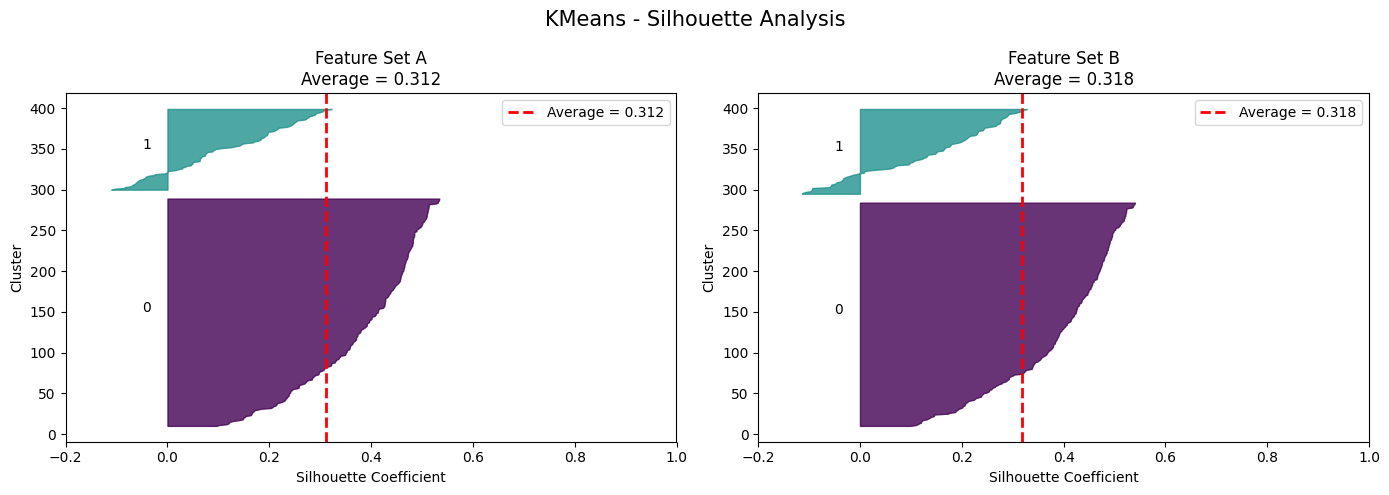

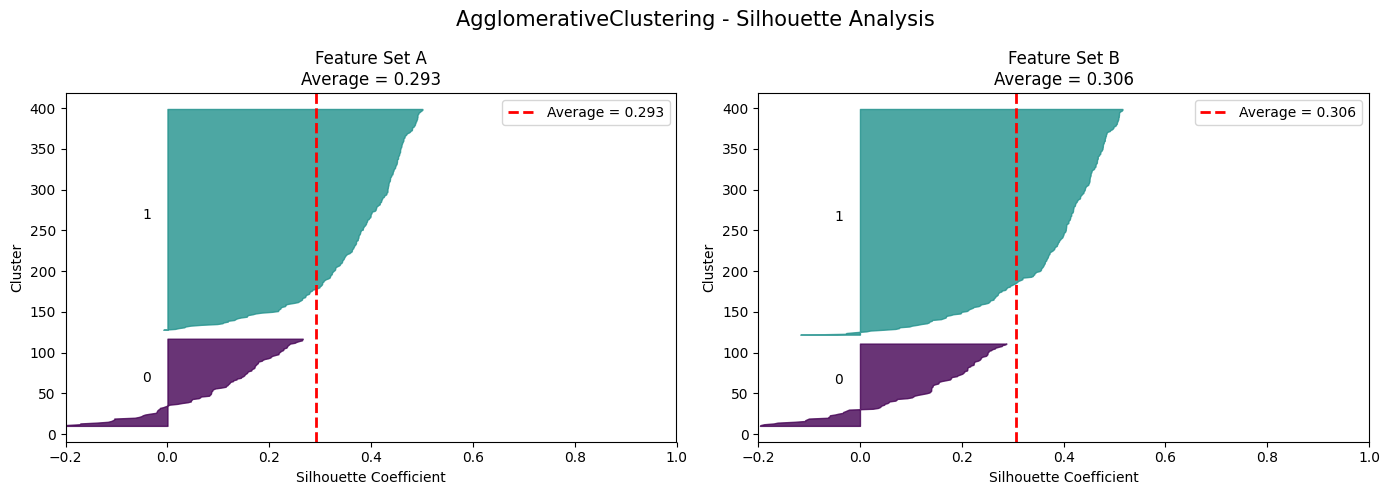

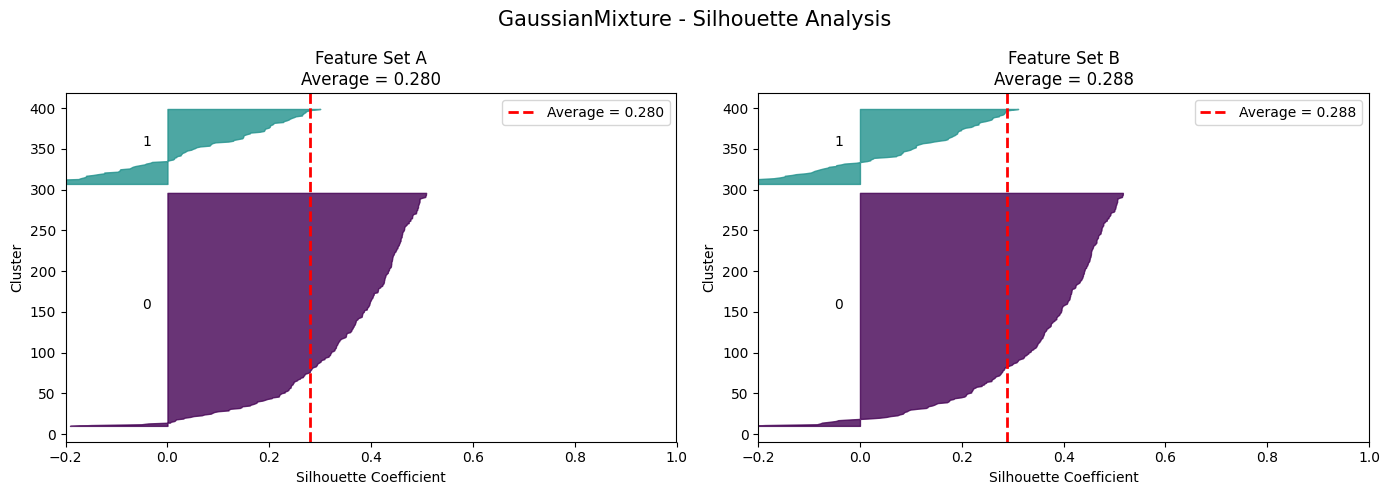

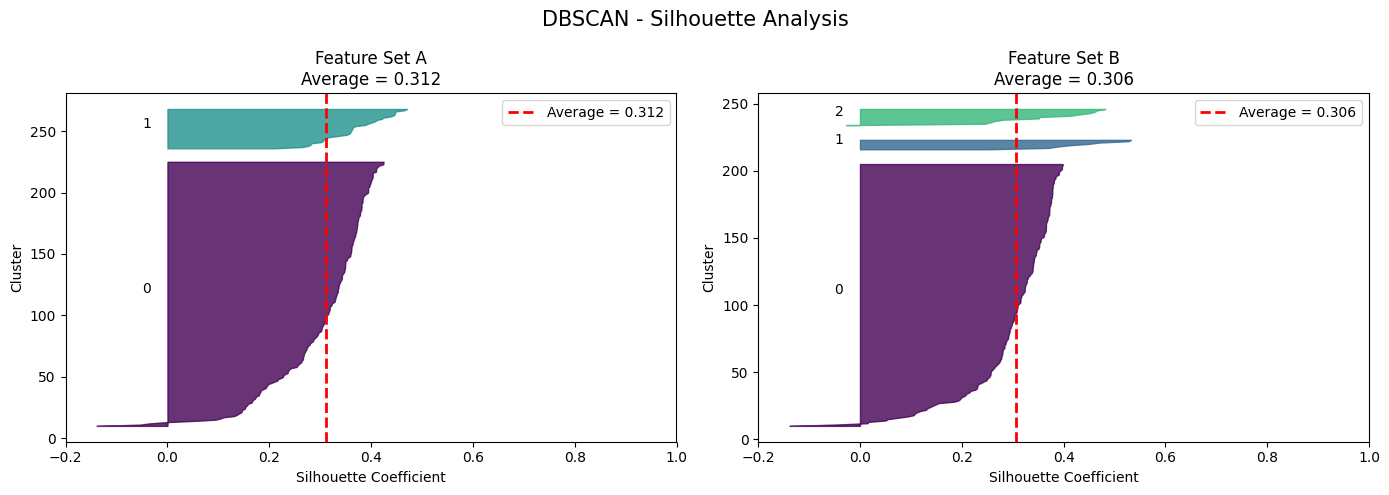

In [18]:
plot_silhouette_analysis(
    X_A,
    X_B,
    X_A_clusters,
    X_B_clusters,
    "KMeans"
)

plot_silhouette_analysis(
    X_A,
    X_B,
    X_A_clusters,
    X_B_clusters,
    "AgglomerativeClustering"
)

plot_silhouette_analysis(
    X_A,
    X_B,
    X_A_clusters,
    X_B_clusters,
    "GaussianMixture"
)

plot_silhouette_analysis(
    X_A,
    X_B,
    X_A_clusters,
    X_B_clusters,
    "DBSCAN"
)

> Interpretation: Each colored band corresponds to one cluster. Wider bands indicate larger clusters, while the thickness of the band reflects the number of samples assigned to that cluster. The vertical dashed red line represents the average silhouette score of the clustering solution. Ideally, most samples should lie to the right of zero, indicating good cluster assignment. Samples with negative silhouette values may be closer to neighboring clusters and could represent ambiguous assignments or potential misclassifications.

### 3) Build up results and store
- Adding cluster column to the set
- Counting the number of samples in each cluster
- Calculating clusters characteristics

In [19]:
def resulting(X, clusters):
    # Make copy of the feature set
    results = X.copy()
    # Add clusters to the set
    results["Cluster"] = clusters
    # Count number of samples in each cluster
    sample_counts = results["Cluster"].value_counts().sort_index()
    # Return clusters characteristics
    cluster_char = results.groupby("Cluster").mean(numeric_only=True)

    return results, sample_counts, cluster_char



In [20]:
def apply_resulting(clt_algo, X_A_clusters, X_B_clusters):

    # Store complete result tables
    results = {}

    # Store sample counts
    sample_counts_rows = []

    # Store cluster characteristics
    cluster_char_rows = []

    for name in clt_algo.keys():

        clusters = f"{name} Clusters"

        # ==========================
        # Feature Set A
        # ==========================

        res_A, count_A, char_A = resulting(X_A, X_A_clusters[clusters])

        results[f"{name}_A"] = res_A

        count_df_A = count_A.reset_index()
        count_df_A.columns = ["Cluster", "Count"]
        count_df_A["Algorithm"] = name
        count_df_A["Feature Set"] = "A"

        sample_counts_rows.append(count_df_A)

        char_df_A = (
            char_A
            .reset_index()
            .melt(id_vars="Cluster",
                  var_name="Feature",
                  value_name="Mean")
        )

        char_df_A["Algorithm"] = name
        char_df_A["Feature Set"] = "A"

        cluster_char_rows.append(char_df_A)


        # ==========================
        # Feature Set B
        # ==========================

        res_B, count_B, char_B = resulting(X_B, X_B_clusters[clusters])

        results[f"{name}_B"] = res_B

        count_df_B = count_B.reset_index()
        count_df_B.columns = ["Cluster", "Count"]
        count_df_B["Algorithm"] = name
        count_df_B["Feature Set"] = "B"

        sample_counts_rows.append(count_df_B)

        char_df_B = (
            char_B
            .reset_index()
            .melt(id_vars="Cluster",
                  var_name="Feature",
                  value_name="Mean")
        )

        char_df_B["Algorithm"] = name
        char_df_B["Feature Set"] = "B"

        cluster_char_rows.append(char_df_B)


    sample_counts_df = pd.concat(sample_counts_rows, ignore_index=True)
    cluster_char_df = pd.concat(cluster_char_rows, ignore_index=True)

    return results, sample_counts_df, cluster_char_df


results, sample_counts_df, cluster_char_df = apply_resulting(
    clt_algo,
    X_A_clusters,
    X_B_clusters
)

### - Inspect results set

In [21]:
results["KMeans_A"].head() # Just a random peek

,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,...,nom__Pathology_Follicular,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage,Cluster
0,-0.923305,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0
1,-0.460609,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0
2,-0.725007,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0
3,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0
4,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0


### - Samples counts in each cluster

In [22]:
sample_counts_df

,Cluster,Count,Algorithm,Feature Set
0,0,280,KMeans,A
1,1,100,KMeans,A
2,0,275,KMeans,B
3,1,105,KMeans,B
4,-1,131,DBSCAN,A
5,0,216,DBSCAN,A
6,1,33,DBSCAN,A
7,-1,163,DBSCAN,B
8,0,196,DBSCAN,B
9,1,8,DBSCAN,B


In [23]:
# A helper function to get the sample counts of clusters in the corresponding set
def sample_per_algo_set(algo, feature_set):
    return (
        sample_counts_df.loc[
            (sample_counts_df["Algorithm"] == algo) &
            (sample_counts_df["Feature Set"] == feature_set)
        ]
        .sort_values("Cluster")
        .reset_index(drop=True)
    )

In [24]:
sample_per_algo_set("KMeans", "A")  # Use

,Cluster,Count,Algorithm,Feature Set
0,0,280,KMeans,A
1,1,100,KMeans,A


In [25]:
# --------------------------------------------------------------------------------------
# Plot sample counts in each cluster in the corresponding set using Bar and Pie plots
# --------------------------------------------------------------------------------------
def plot_sample_counts(algo):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    feature_sets = ["A", "B"]

    for row, feature_set in enumerate(feature_sets):

        df = sample_per_algo_set(algo, feature_set)

        clusters = df["Cluster"].astype(str)
        counts = df["Count"]

        # -------------------------
        # Bar Plot
        # -------------------------
        ax = axes[row, 0]

        bars = ax.bar(clusters, counts, color="firebrick")

        ax.set_title(f"{algo} - Feature Set {feature_set}")
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Number of Samples")
        ax.grid(alpha=0.5)

        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f"{int(bar.get_height())}",
                ha="center",
                va="bottom",
                fontsize=10
            )

        # -------------------------
        # Pie Chart
        # -------------------------
        ax = axes[row, 1]

        ax.pie(
        counts,
        labels=[f"{i}" for i in clusters],
        autopct="%1.1f%%",
        startangle=90,
        colors=["salmon", "mediumspringgreen", "royalblue", "khaki"],
        pctdistance=1.15,   # percentages farther out
        labeldistance=0.7   # labels closer to center
        )

        ax.set_title(f"{algo} - Feature Set {feature_set}")

    plt.suptitle(f"{algo} Sample Distribution", fontsize=16)

    plt.tight_layout()
    plt.show()

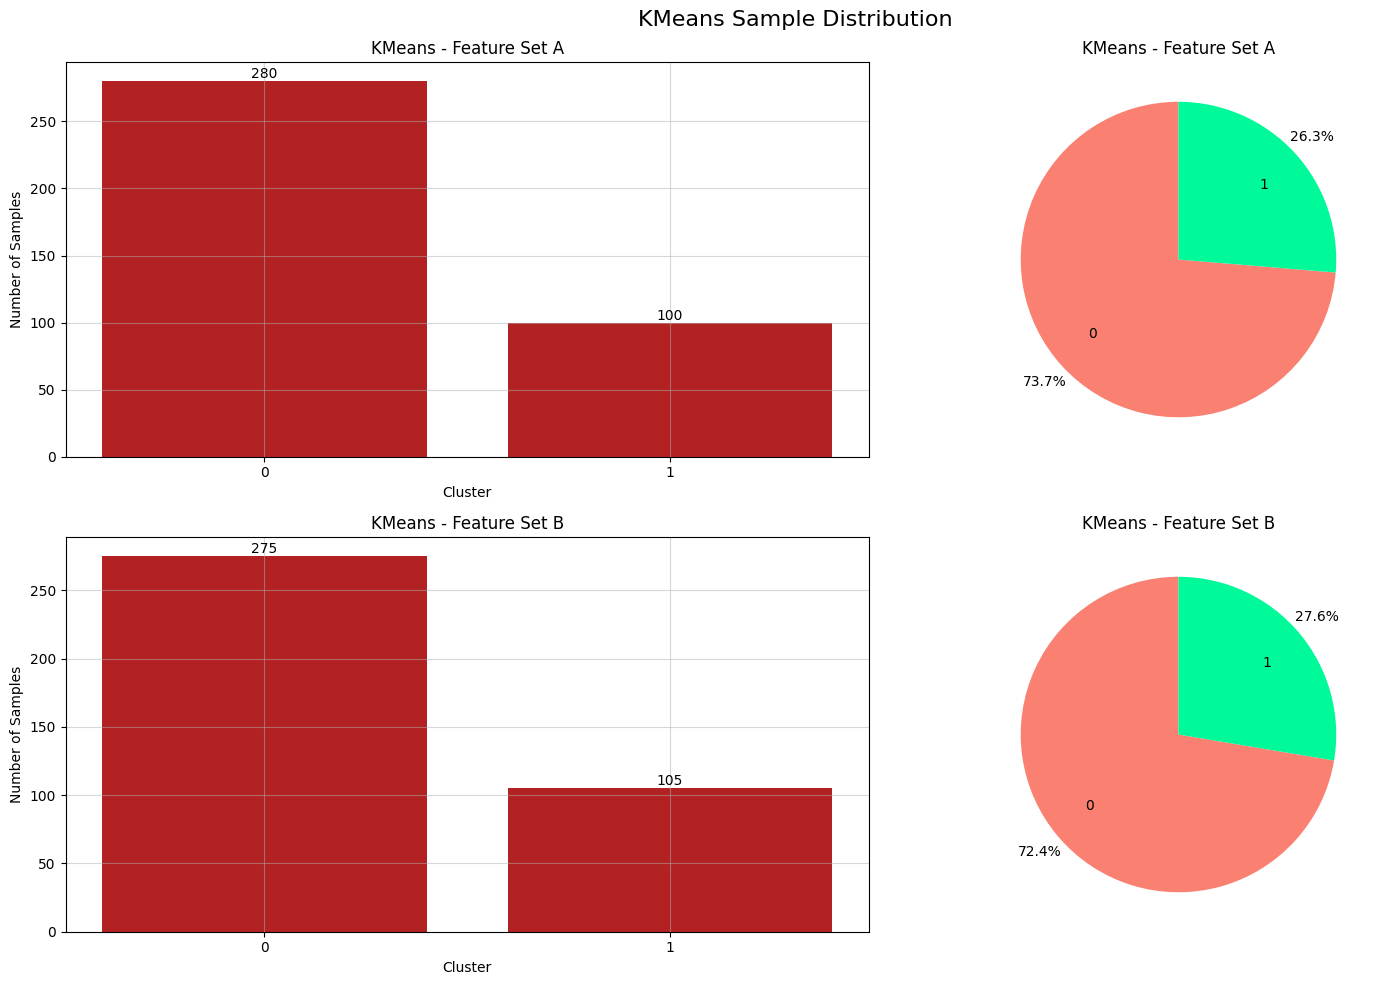

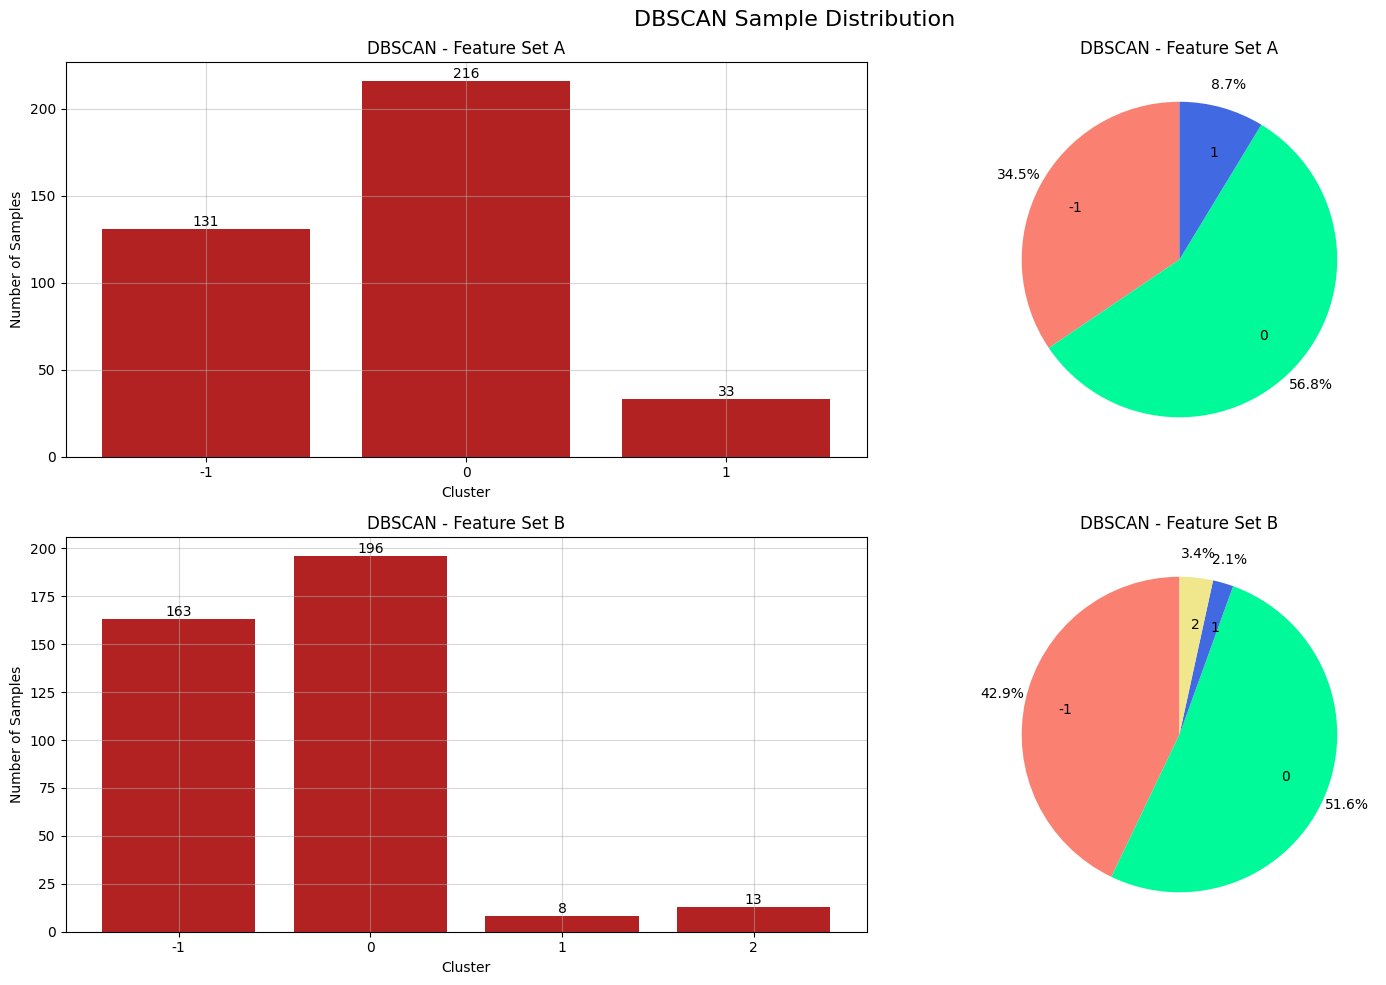

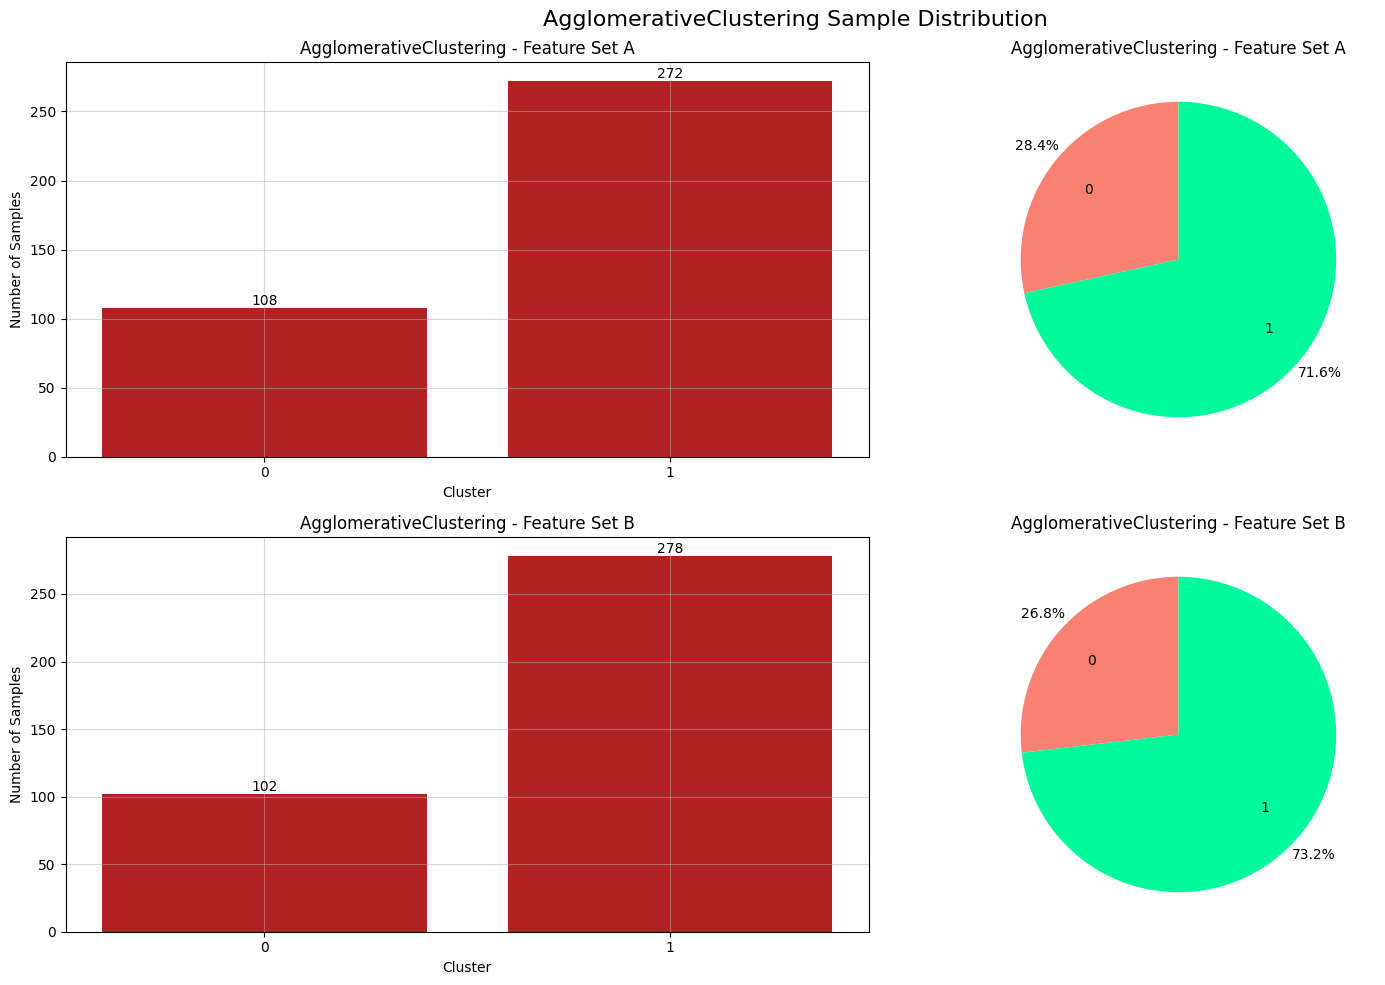

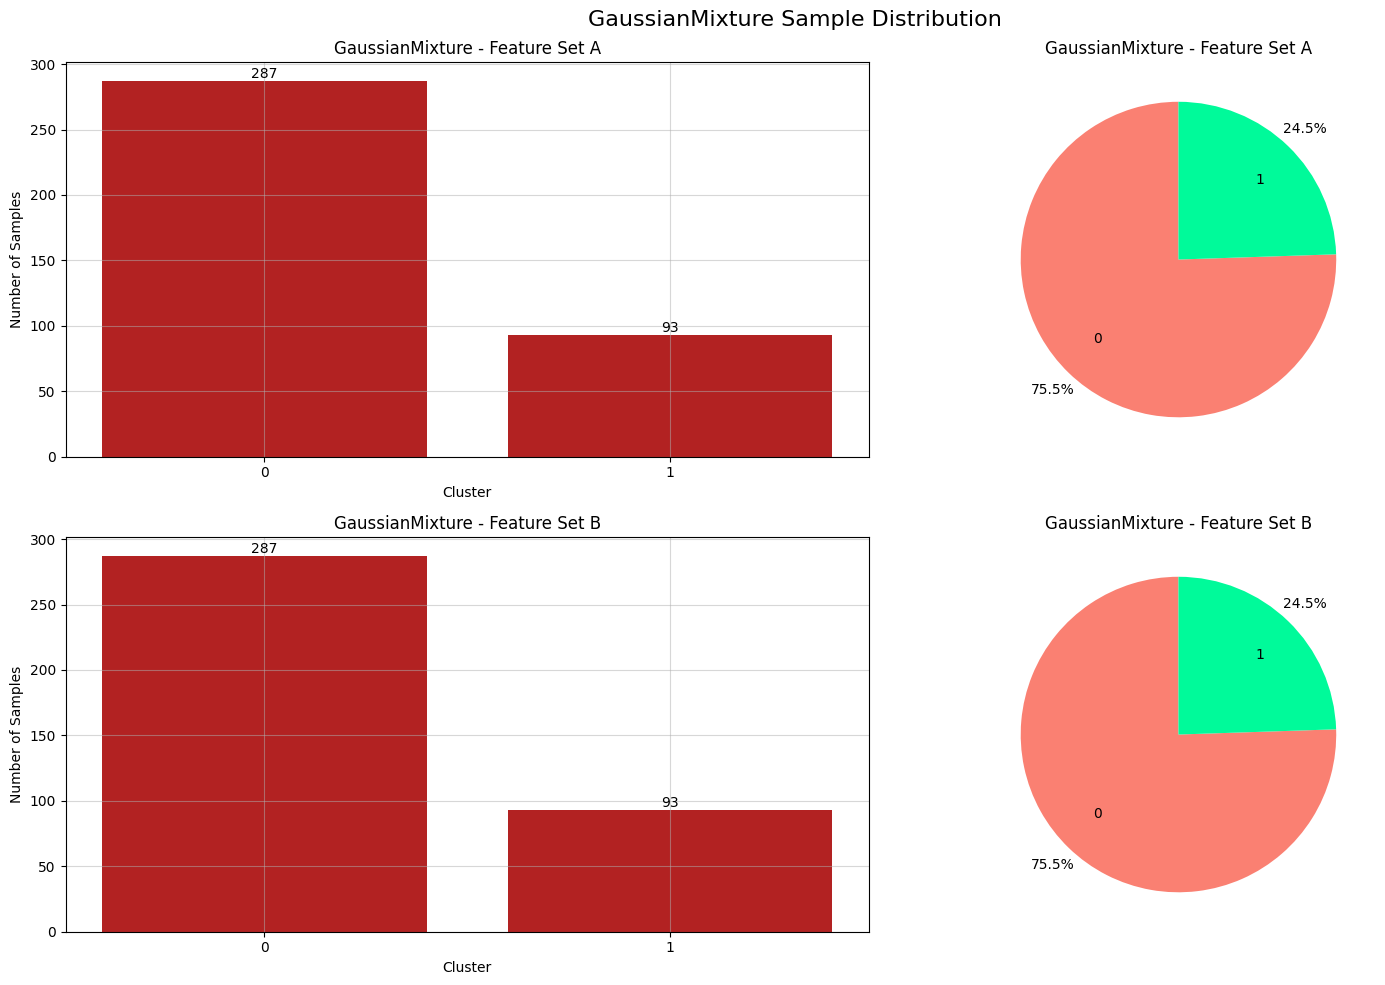

In [26]:
for algo in sample_counts_df["Algorithm"].unique():
    plot_sample_counts(algo)

### - Clusters Characteristics

In [27]:
cluster_char_df

,Cluster,Feature,Mean,Algorithm,Feature Set
0,0,con_num__Age,-0.207070,KMeans,A
1,1,con_num__Age,0.579797,KMeans,A
2,0,bin__Gender_F,0.882143,KMeans,A
3,1,bin__Gender_F,0.620000,KMeans,A
4,0,bin__Gender_M,0.117857,KMeans,A
...,...,...,...,...,...
689,1,ord__M,0.193548,GaussianMixture,B
690,0,ord__Stage,0.000000,GaussianMixture,B
691,1,ord__Stage,1.000000,GaussianMixture,B
692,0,ord__Response,1.285714,GaussianMixture,B


In [29]:
cluster_char_df = cluster_char_df.rename(columns=rename_dict)

In [30]:
# A helper function to get the clusters characteristics in each algorithms and feature set
def clusterChar_per_algo_set(algo, feature_set):
    df = cluster_char_df[
        (cluster_char_df["Algorithm"] == algo) &
        (cluster_char_df["Feature Set"] == feature_set)
    ]

    return df.pivot(
        index="Cluster",
        columns="Feature",
        values="Mean"
    )

In [31]:
clusterChar_per_algo_set("KMeans", "A") # Peek

Feature,bin__Focality_Multi-Focal,bin__Focality_Uni-Focal,bin__Gender_F,bin__Gender_M,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Smoking_No,bin__Smoking_Yes,...,nom__Thyroid Function_Clinical Hyperthyroidism,nom__Thyroid Function_Clinical Hypothyroidism,nom__Thyroid Function_Euthyroid,nom__Thyroid Function_Subclinical Hyperthyroidism,nom__Thyroid Function_Subclinical Hypothyroidism,ord__M,ord__N,ord__Risk,ord__Stage,ord__T
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.196429,0.803571,0.882143,0.117857,0.996429,0.003571,0.95,0.05,0.942857,0.057143,...,0.053571,0.035714,0.867857,0.017857,0.025,0.00,0.20,1.860714,0.007143,1.678571
1,0.810000,0.190000,0.620000,0.380000,0.940000,0.060000,0.86,0.14,0.670000,0.330000,...,0.050000,0.020000,0.860000,0.000000,0.070,0.18,1.52,0.730000,0.910000,3.690000


In [32]:

def plot_cluster_char(cluster_char, title=""):

    cluster_char = cluster_char.rename(columns=rename_dict)

    fig, axes = plt.subplots(
        2, 1,
        figsize=(18, 11),
        gridspec_kw={"height_ratios":[2.8,1]}
    )

    # --------------------
    # Bar Plot
    # --------------------
    cluster_char.T.plot(
        kind="bar",
        ax=axes[0],
        width=0.8
    )

    axes[0].set_title(f"{title} Cluster Characteristics")
    axes[0].set_ylabel("Mean Value")
    axes[0].set_xlabel("")
    axes[0].grid(alpha=0.5)
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].legend(title="Cluster")

    # --------------------
    # Heatmap
    # --------------------
    sns.heatmap(
        cluster_char,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot_kws={"size":7},
        ax=axes[1]
    )

    axes[1].set_title("Heatmap")

    plt.tight_layout()
    plt.show()

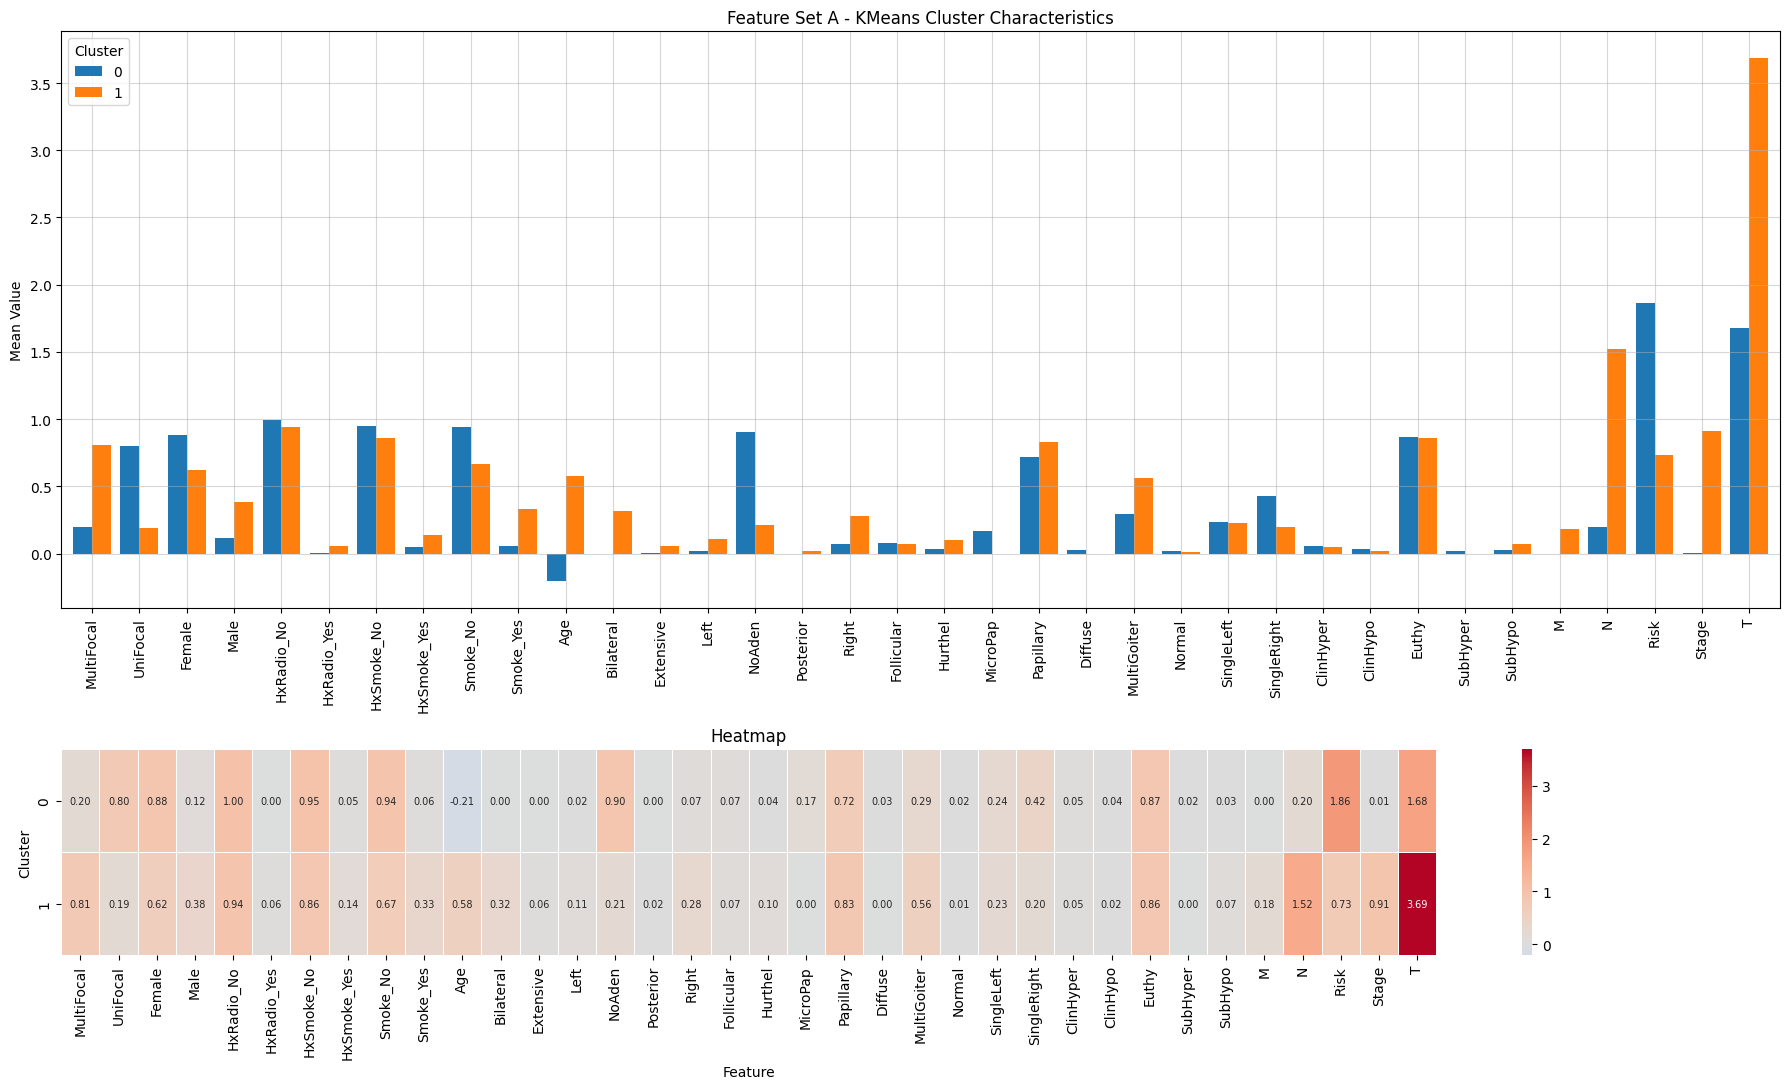

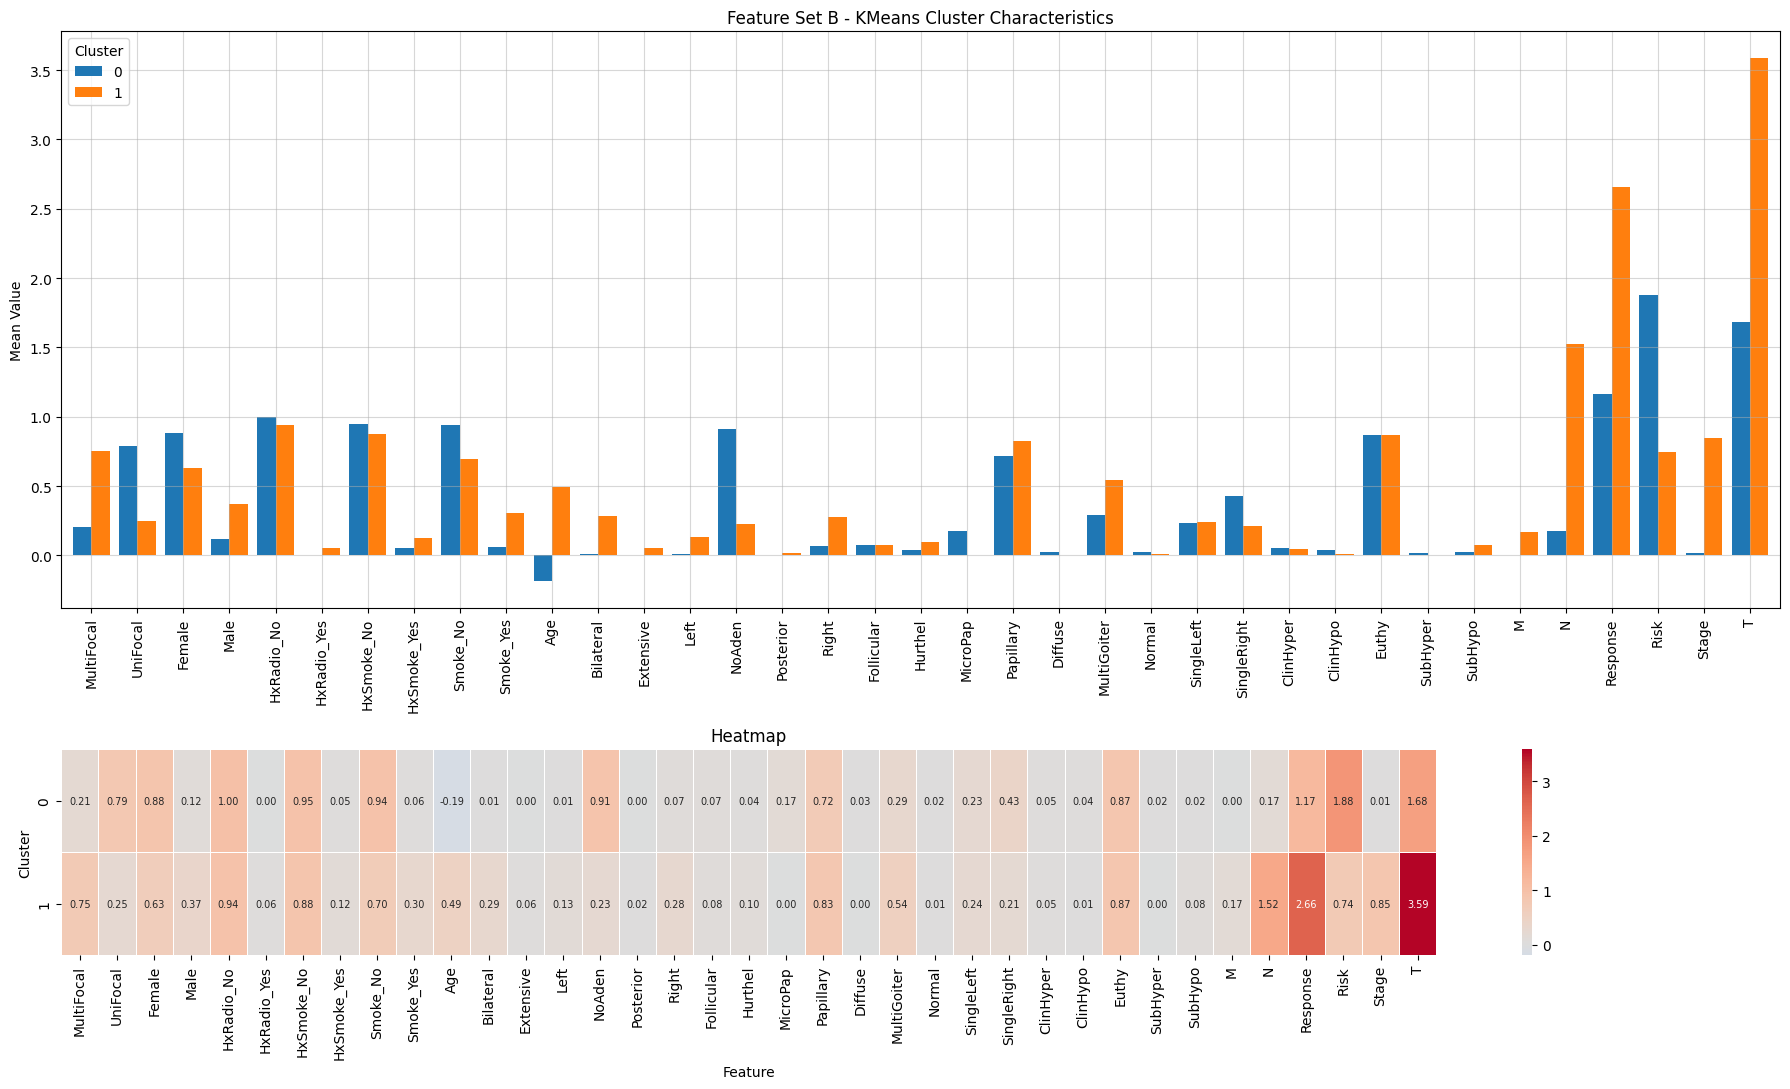

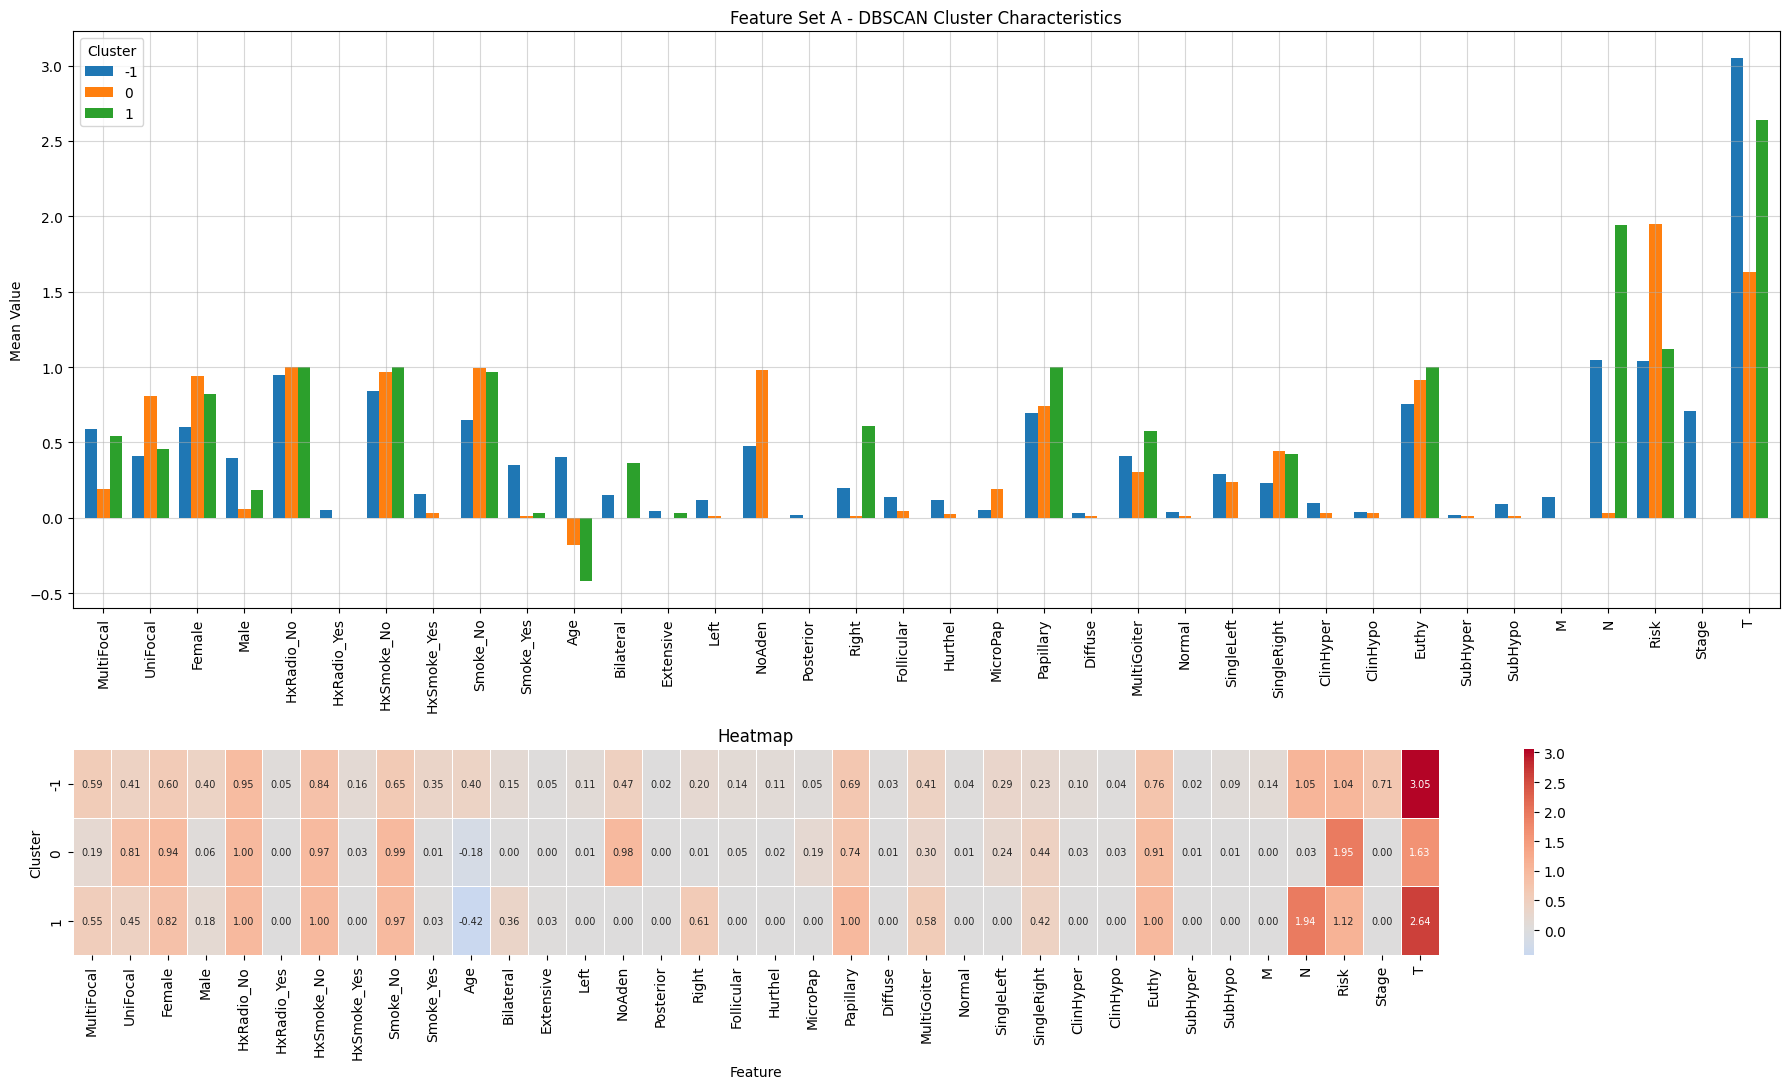

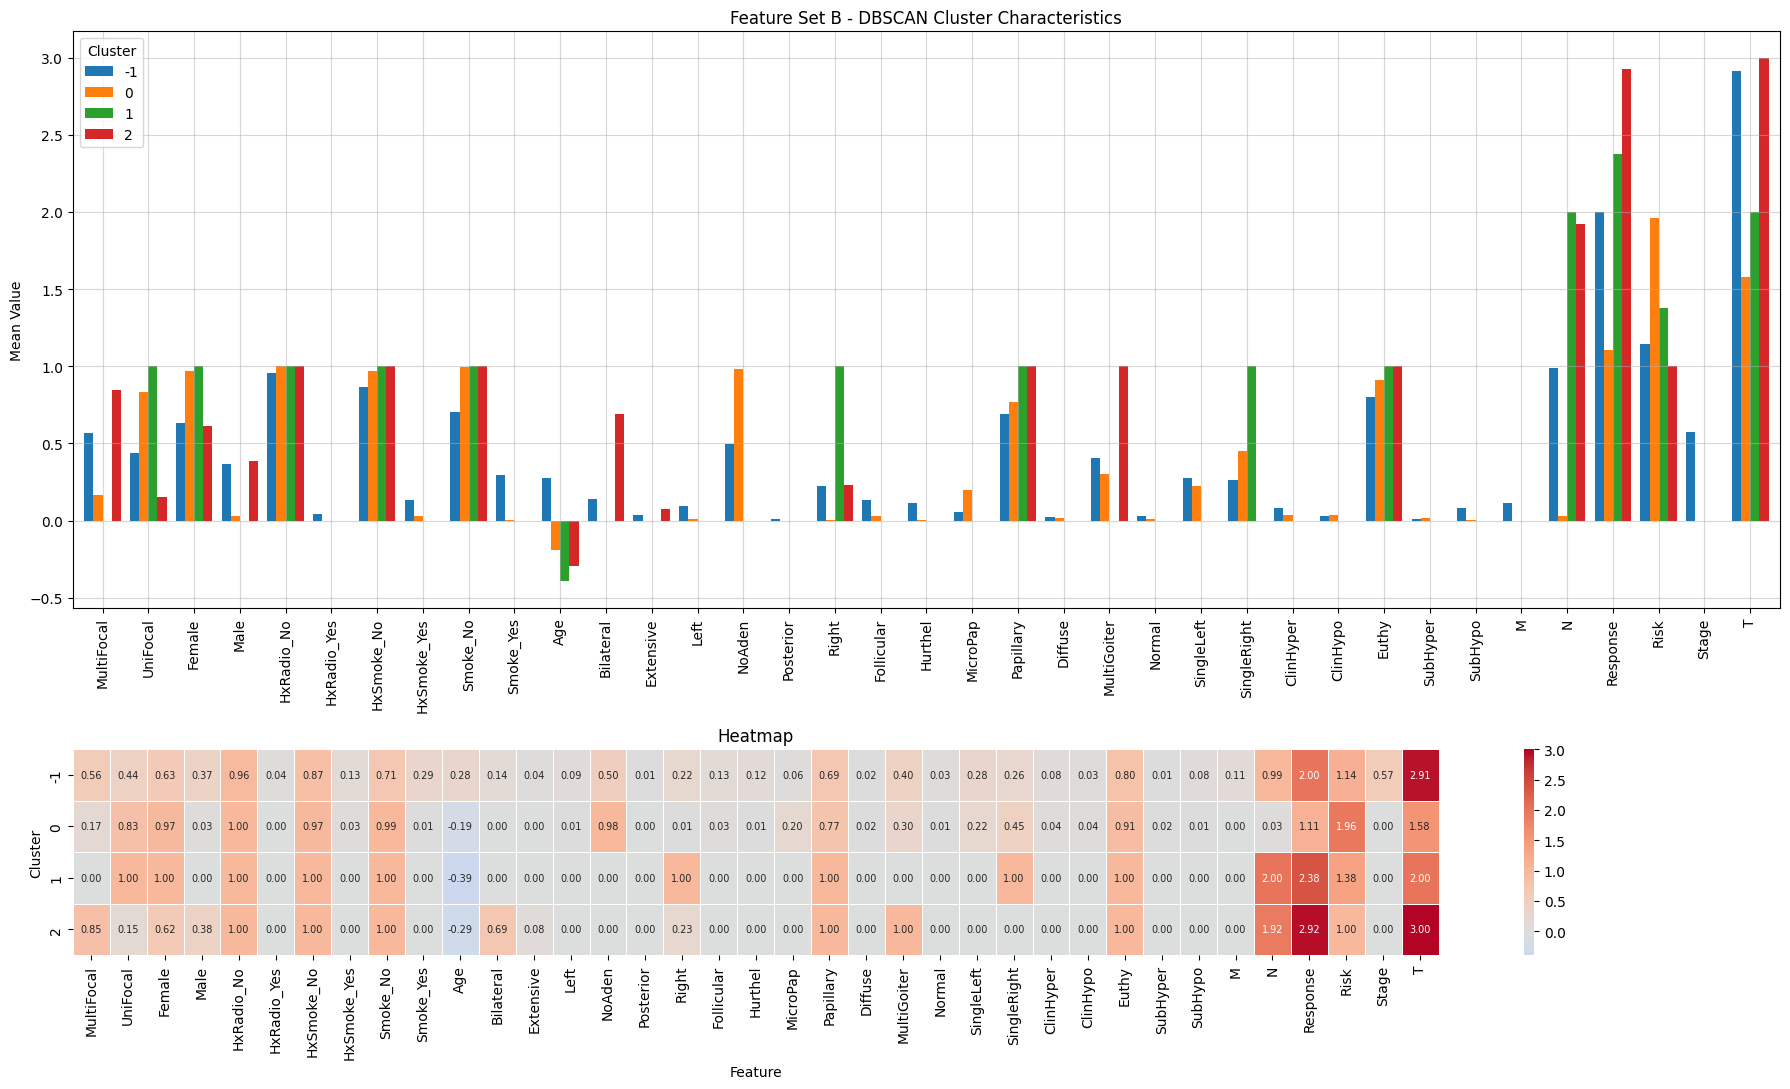

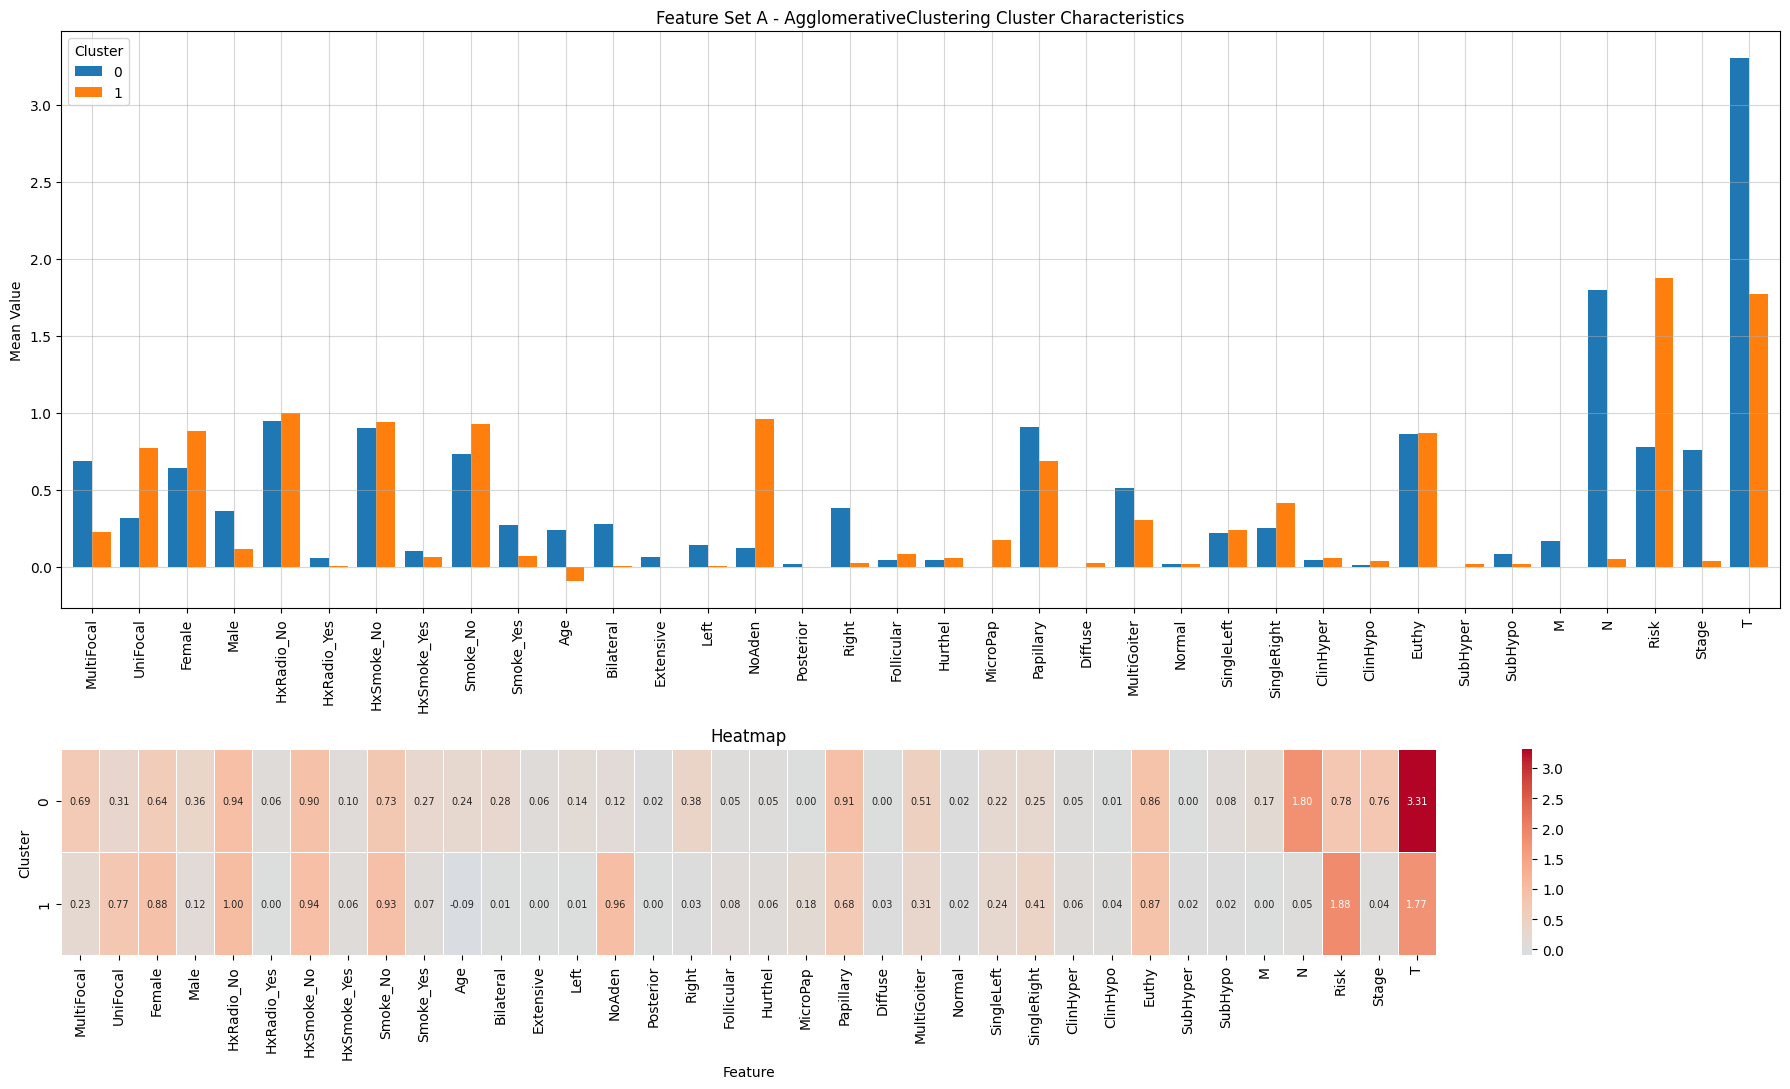

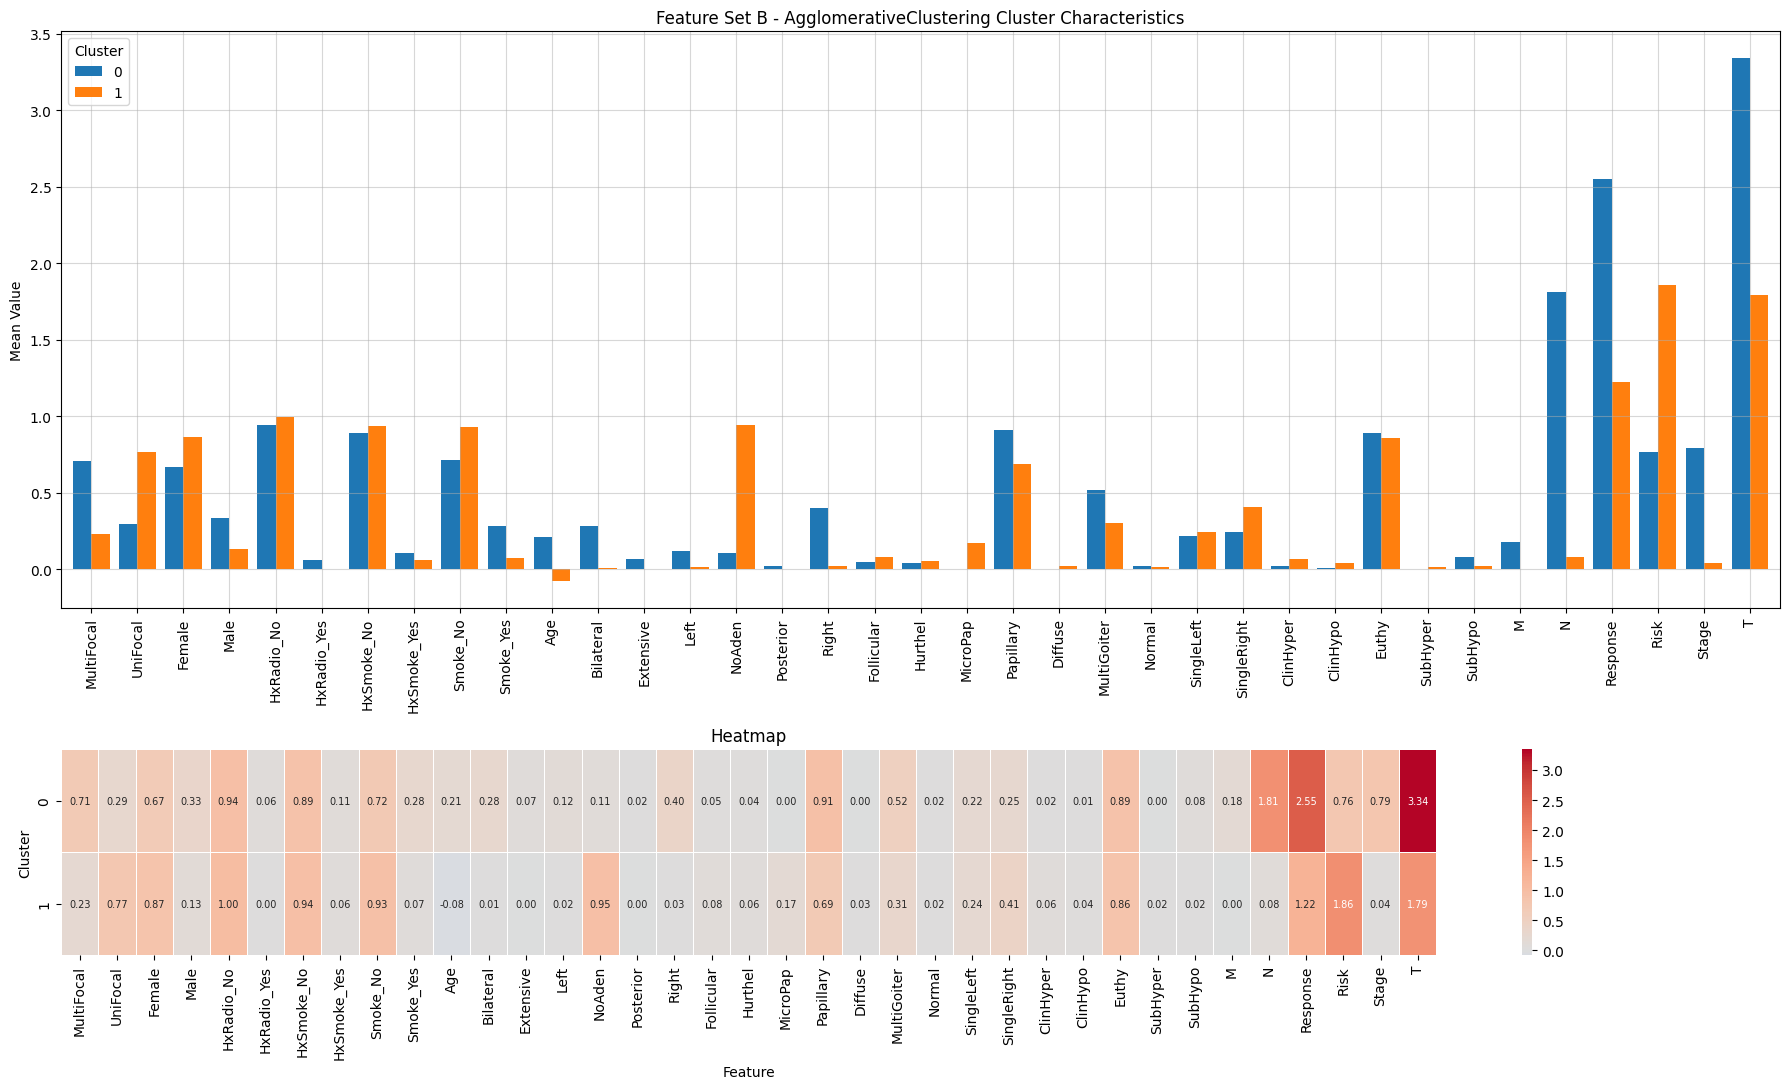

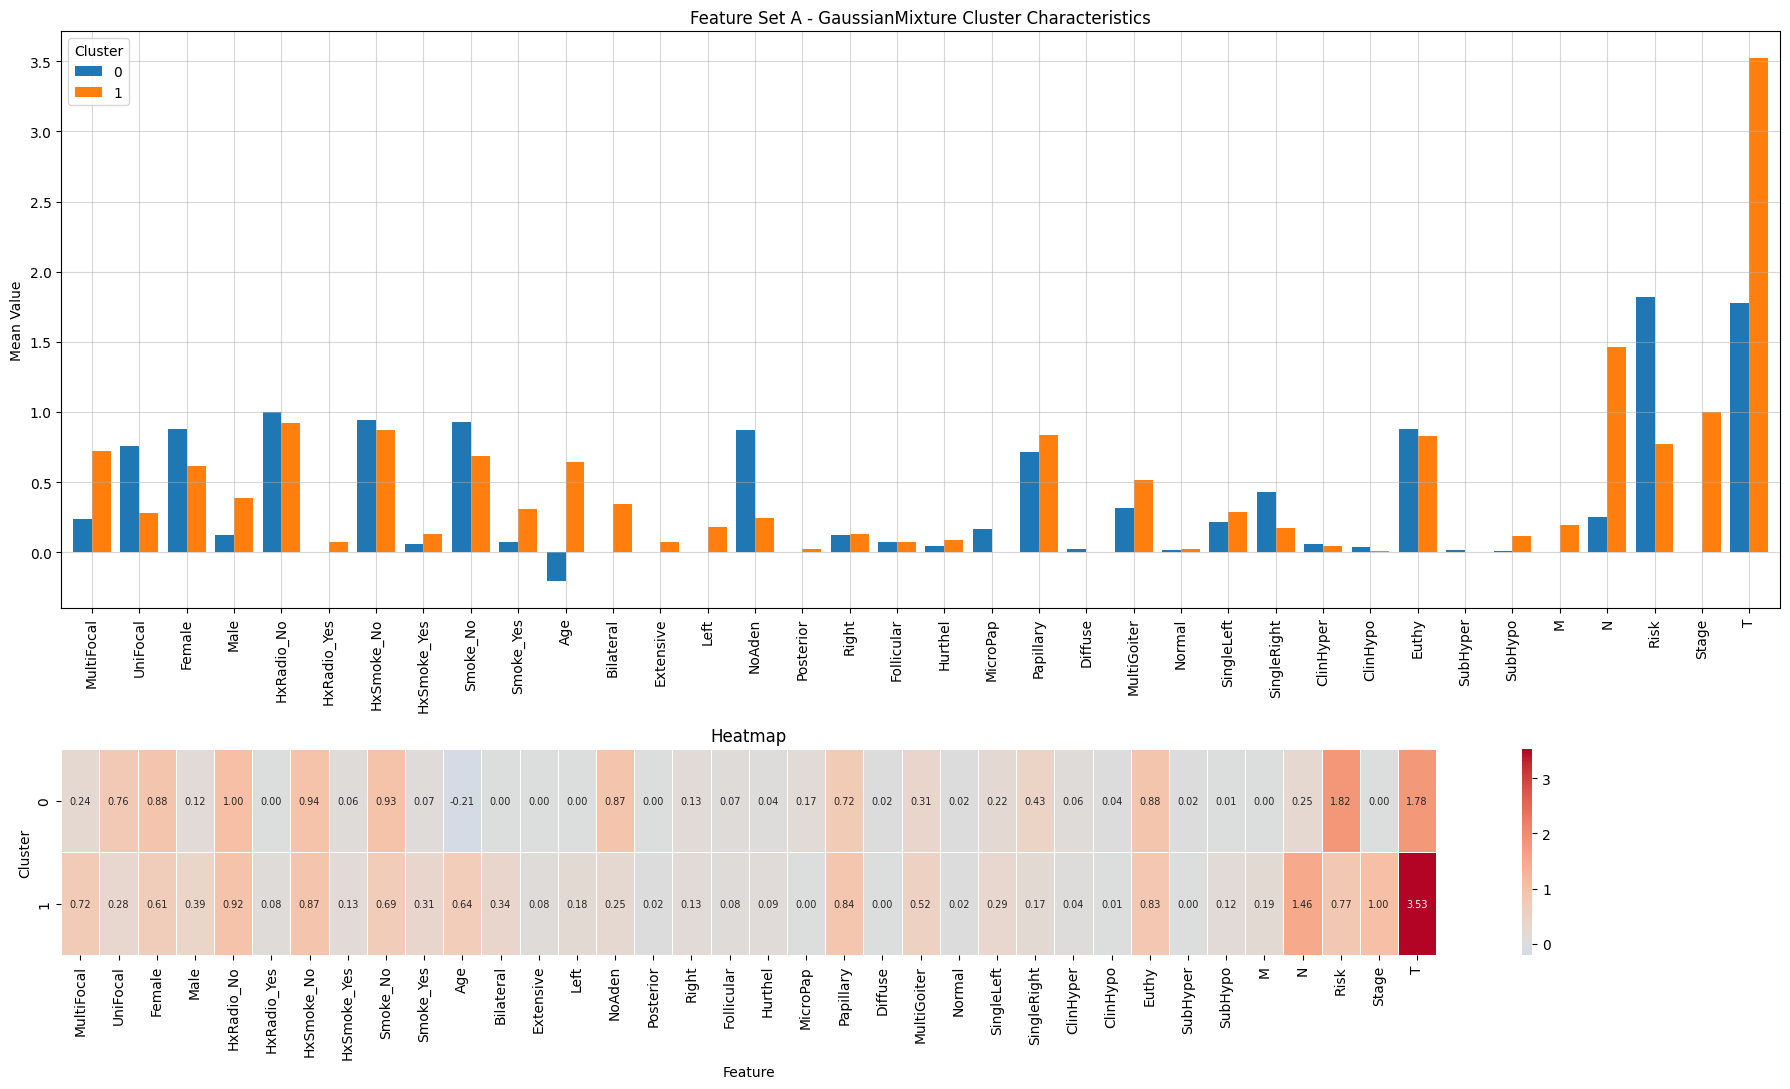

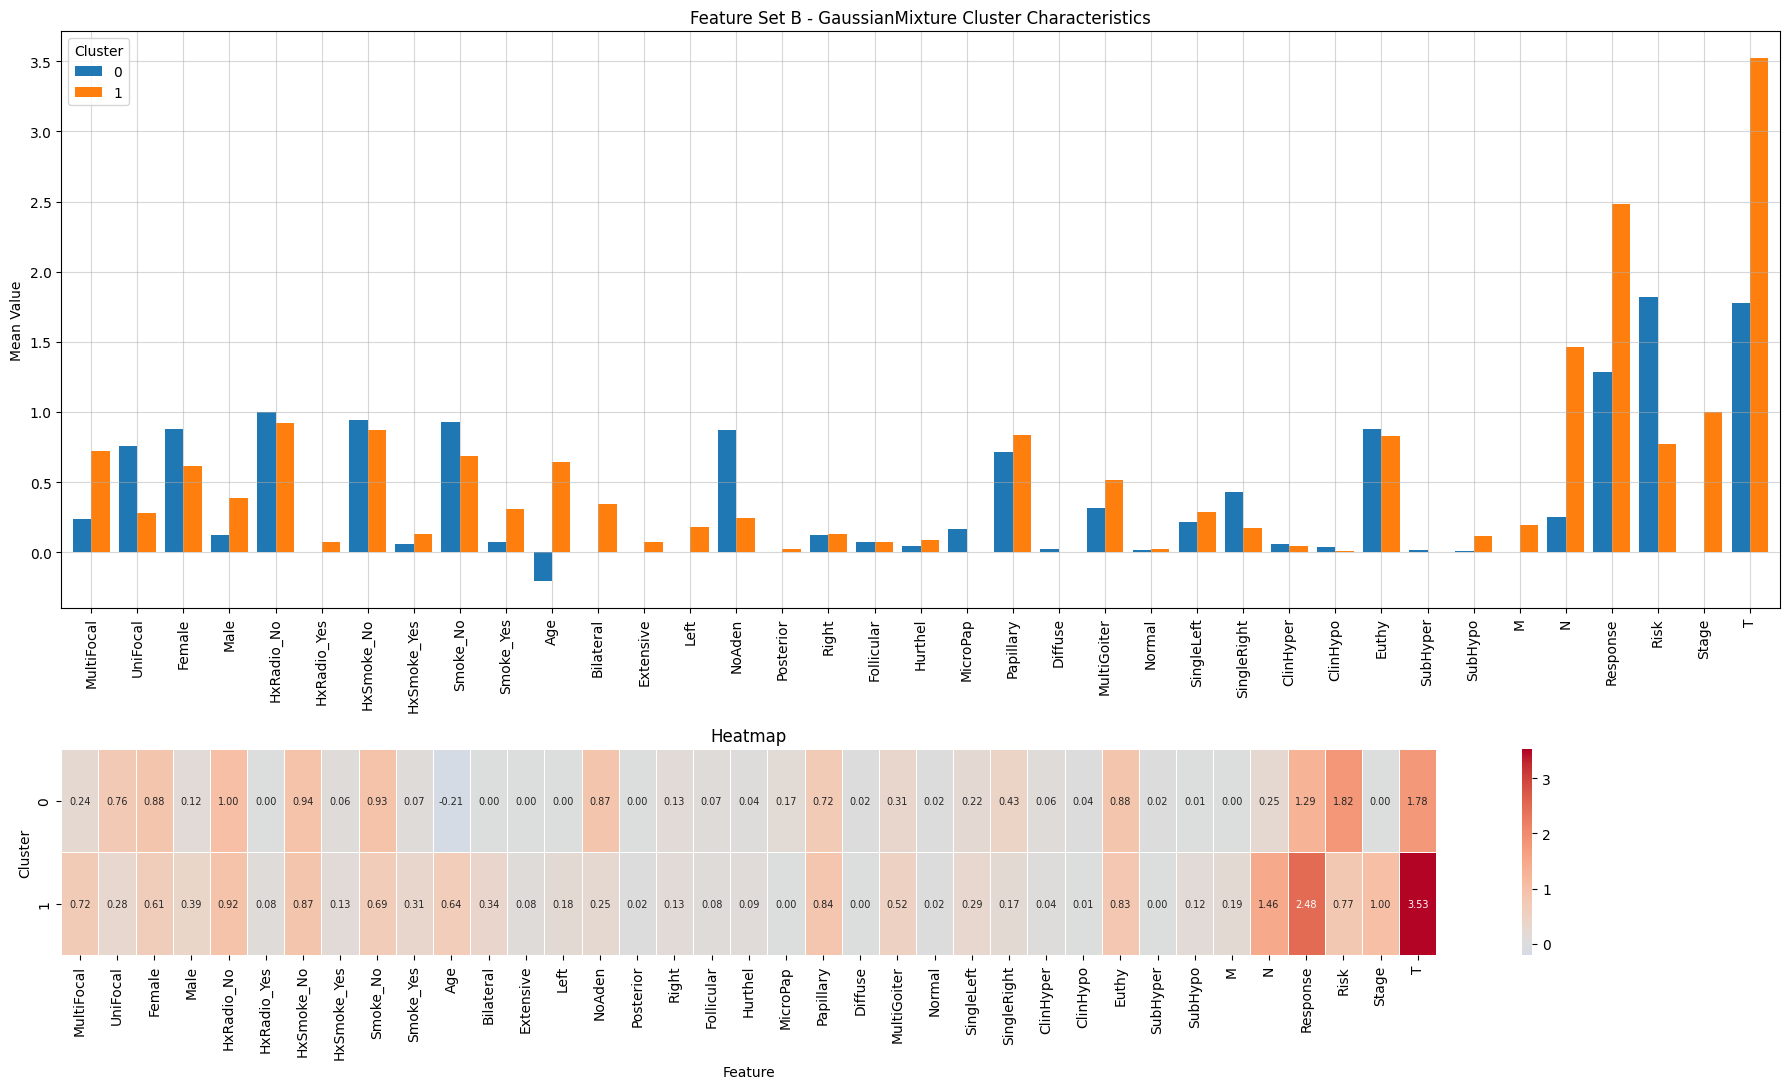

In [33]:
for algo in cluster_char_df["Algorithm"].unique():

    for feature_set in ["A", "B"]:

        cluster_char = clusterChar_per_algo_set(algo, feature_set)

        plot_cluster_char(
            cluster_char,
            f"Feature Set {feature_set} - {algo}"
        )

### 4) Principal Component Analysis (PCA) & Visualization 

#### - Simple Scatter 2D & 3D

In [34]:
def plot_pca(X, clusters, title=""):

    # PCA
    pca2 = PCA(n_components=2)
    X_pca2 = pca2.fit_transform(X)

    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X)

    # Figure
    fig = plt.figure(figsize=(16,6))

    # -------------------------
    # 2D
    # -------------------------
    ax1 = fig.add_subplot(121)

    scatter = ax1.scatter(
        X_pca2[:, 0],
        X_pca2[:, 1],
        c=clusters,
        cmap="viridis",
        alpha=0.7
    )

    # Centroids in PCA space
    unique_clusters = np.unique(clusters)

    for cluster in unique_clusters:
        centroid = X_pca2[clusters == cluster].mean(axis=0)

        ax1.scatter(
            centroid[0],
            centroid[1],
            marker="X",
            s=250,
            c="red",
            edgecolor="black",
            linewidth=2,
            zorder=5
        )

        ax1.text(
            centroid[0],
            centroid[1],
            f"C{cluster}",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            color="white"
        )

    ax1.set_title(
        f"{title} 2 PCs ({pca2.explained_variance_ratio_.sum()*100:.2f}%)"
    )
    ax1.grid(alpha=0.5)
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")

    # -------------------------
    # 3D
    # -------------------------
    ax2 = fig.add_subplot(122, projection="3d")

    scatter = ax2.scatter(
        X_pca3[:, 0],
        X_pca3[:, 1],
        X_pca3[:, 2],
        c=clusters,
        cmap="viridis",
        alpha=0.7
    )

    for cluster in unique_clusters:
        centroid = X_pca3[clusters == cluster].mean(axis=0)

        ax2.scatter(
            centroid[0],
            centroid[1],
            centroid[2],
            marker="X",
            s=250,
            c="red",
            edgecolor="black",
            linewidth=2
        )

    ax2.set_title(
        f"{title} 3 PCs ({pca3.explained_variance_ratio_.sum()*100:.2f}%)"
    )

    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")

    plt.tight_layout()
    plt.show()

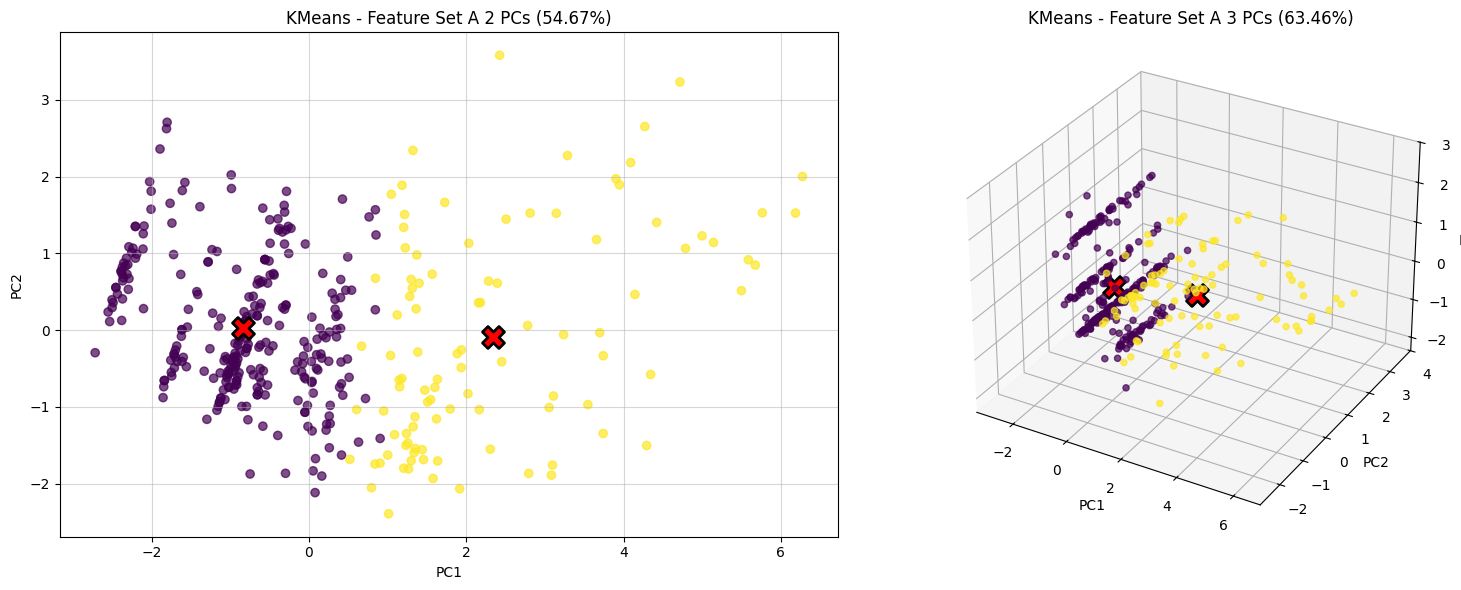

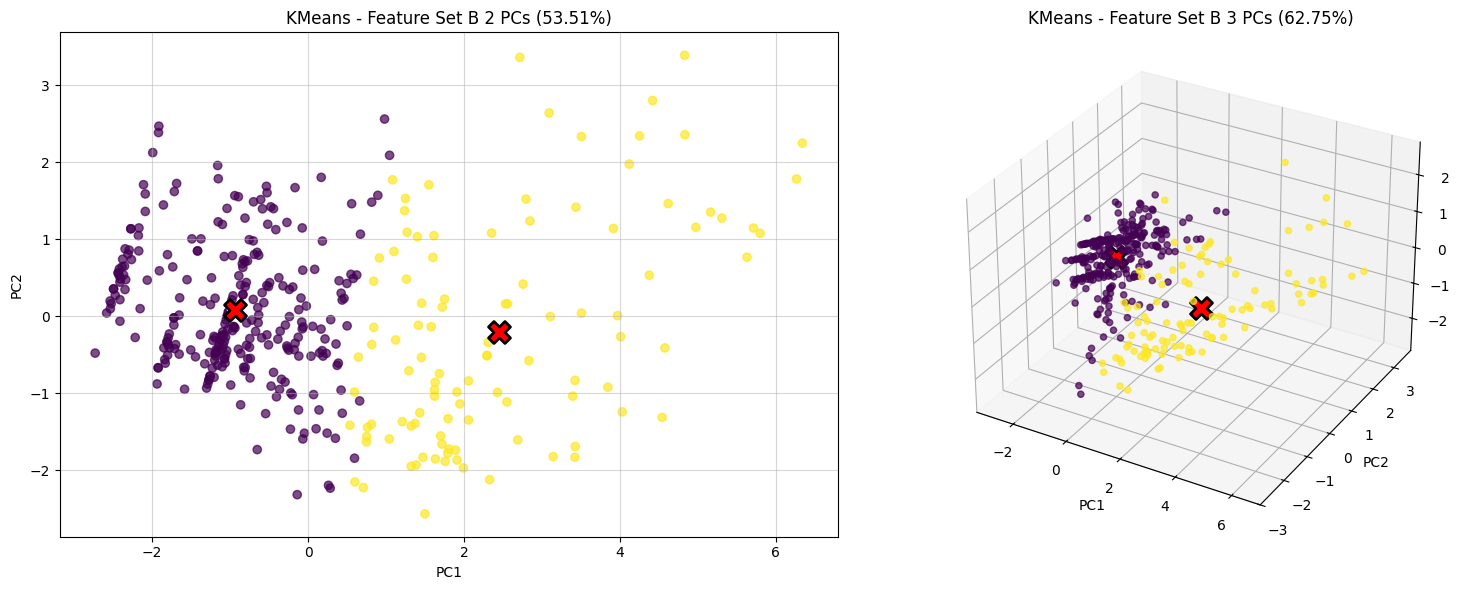

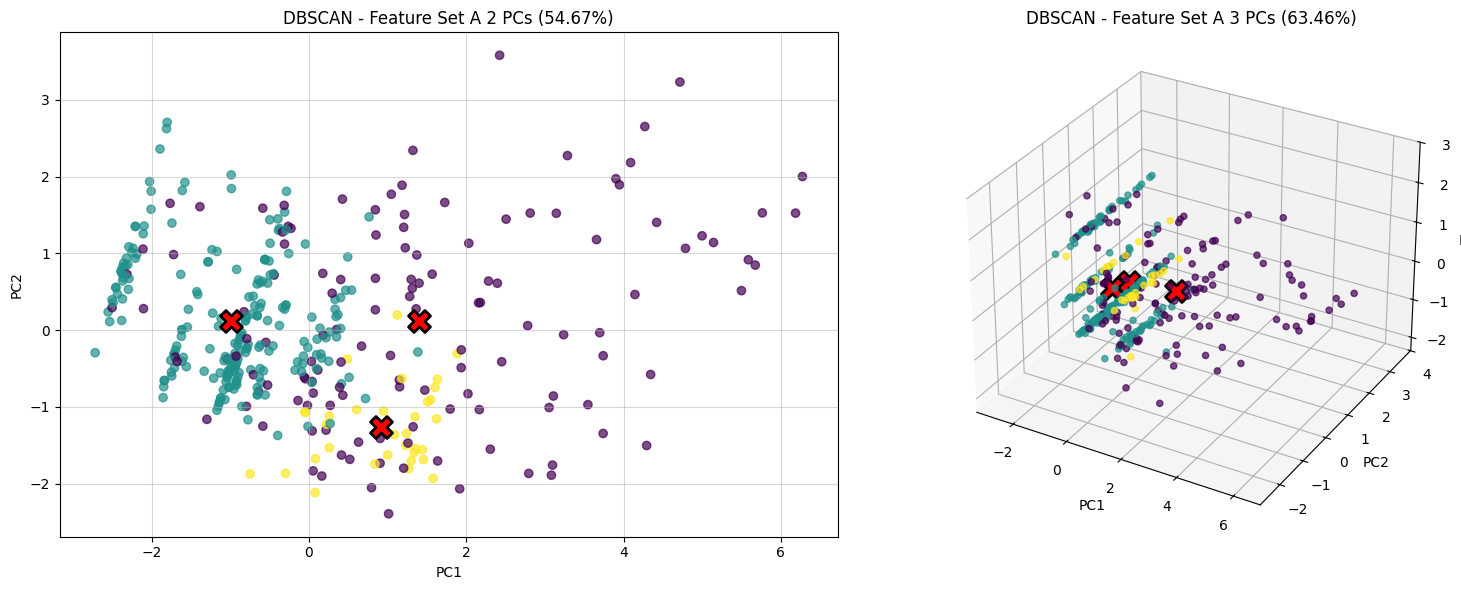

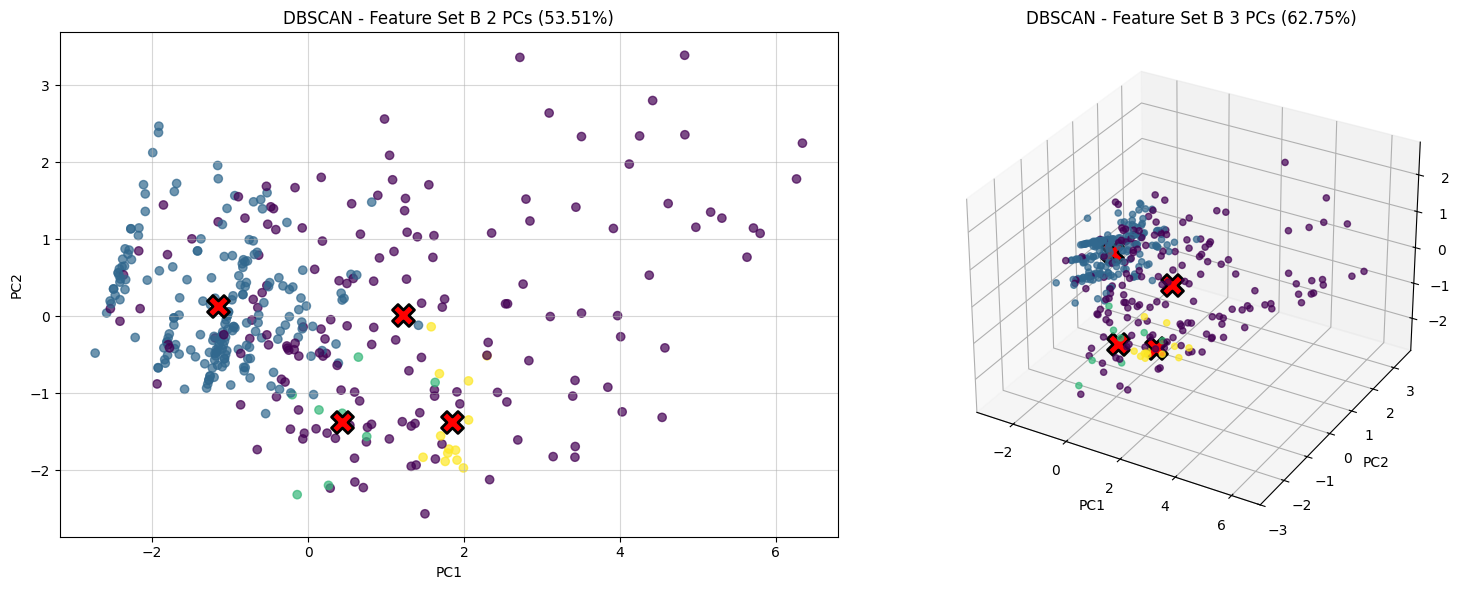

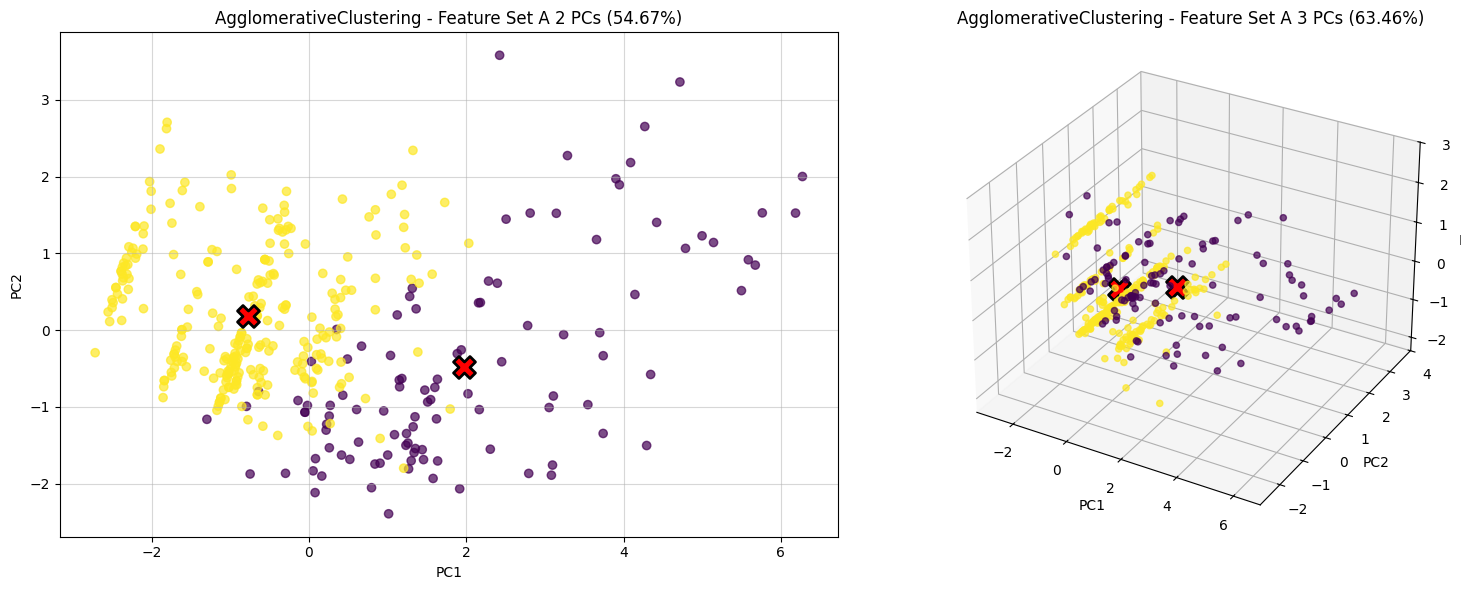

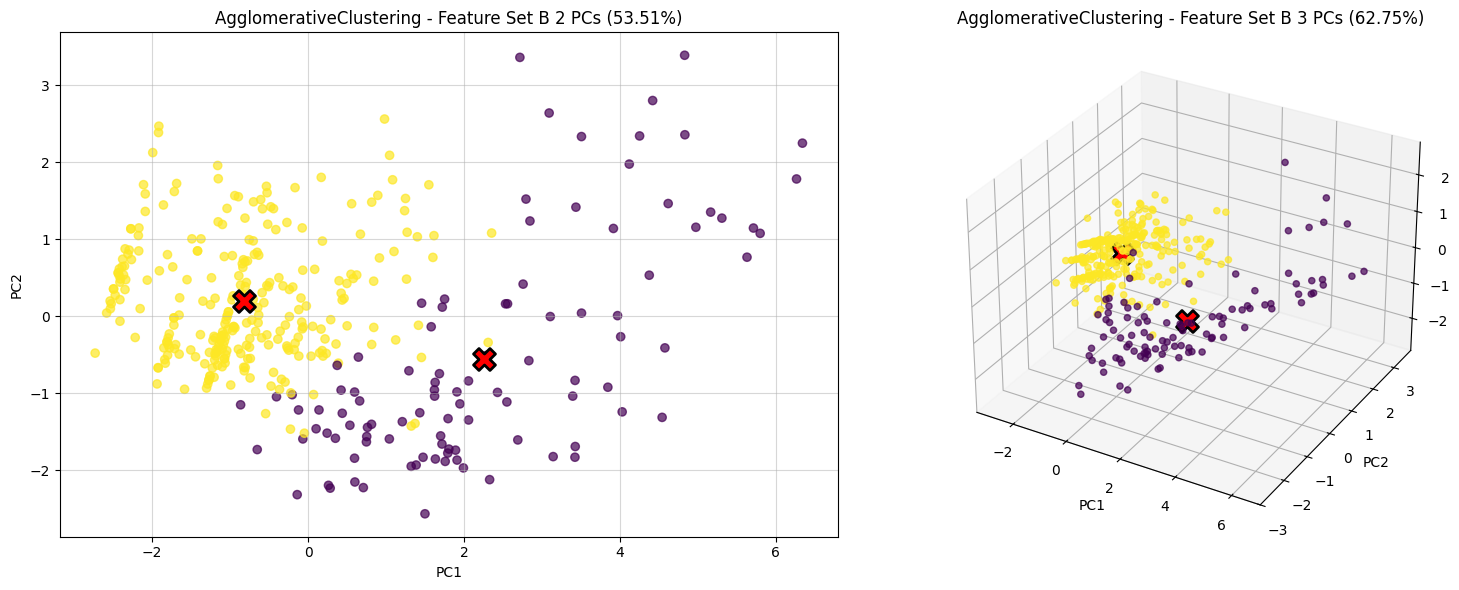

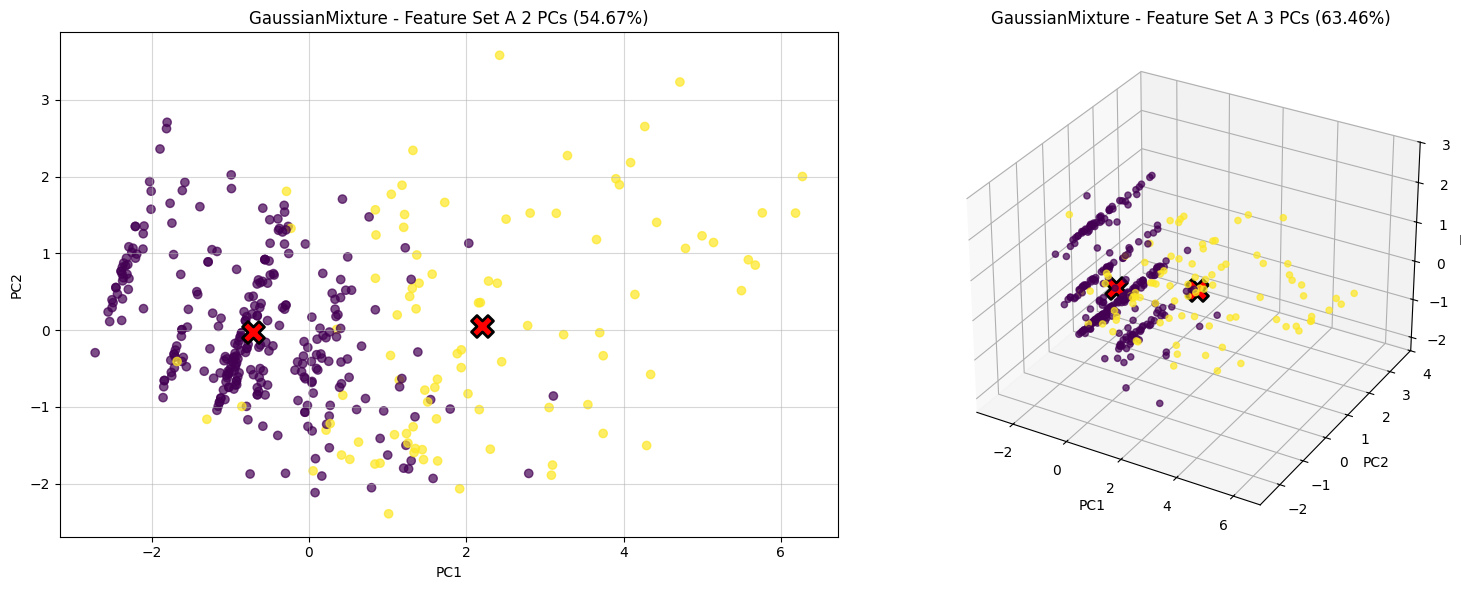

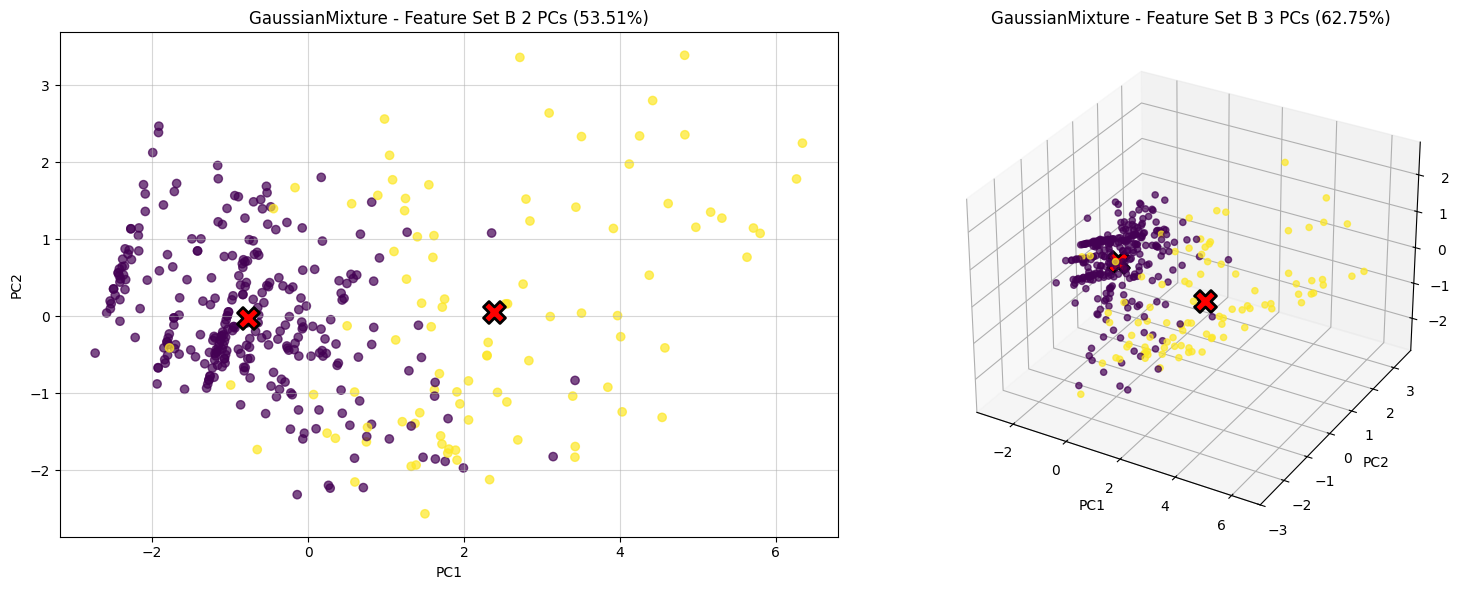

In [35]:
for algo in clt_algo.keys():

    plot_pca(
        X_A,
        X_A_clusters[f"{algo} Clusters"],
        title=f"{algo} - Feature Set A"
    )

    plot_pca(
        X_B,
        X_B_clusters[f"{algo} Clusters"],
        title=f"{algo} - Feature Set B"
    )

#### - Decision boundaries (Voronoi tessellation)
> **Educational Visualization**
>
> The following figure is provided solely to illustrate how the **K-Means** algorithm partitions the feature space into Voronoi-like decision regions. Since the original dataset is high-dimensional (36 features), the data are first projected onto **two principal components (PCA)**, and a new K-Means model is trained in this 2D space for visualization purposes only. This plot is **not** used for model evaluation or interpretation of the clustering results obtained in the original feature space.

In [36]:
# ==========================================================
# Decision Boundary Plot
# ==========================================================

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], "k.", markersize=6)


def plot_centroids(centroids, weights=None,
                   circle_color="white",
                   cross_color="black"):

    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="o",
        s=250,
        linewidths=3,
        color=circle_color,
        edgecolor="black",
        zorder=10,
        alpha=0.9
    )

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=120,
        linewidths=3,
        color=cross_color,
        zorder=11
    )


def plot_decision_boundaries(clusterer,
                             X,
                             resolution=400,
                             show_centroids=True,
                             show_xlabels=True,
                             show_ylabels=True):

    mins = X.min(axis=0) - 0.5
    maxs = X.max(axis=0) + 0.5

    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = clusterer.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(
        xx,
        yy,
        Z,
        cmap="Pastel2",
        alpha=0.8
    )

    plt.contour(
        xx,
        yy,
        Z,
        colors="black",
        linewidths=0.5
    )

    plot_data(X)

    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("PC1")
    else:
        plt.tick_params(labelbottom=False)

    if show_ylabels:
        plt.ylabel("PC2")
    else:
        plt.tick_params(labelleft=False)


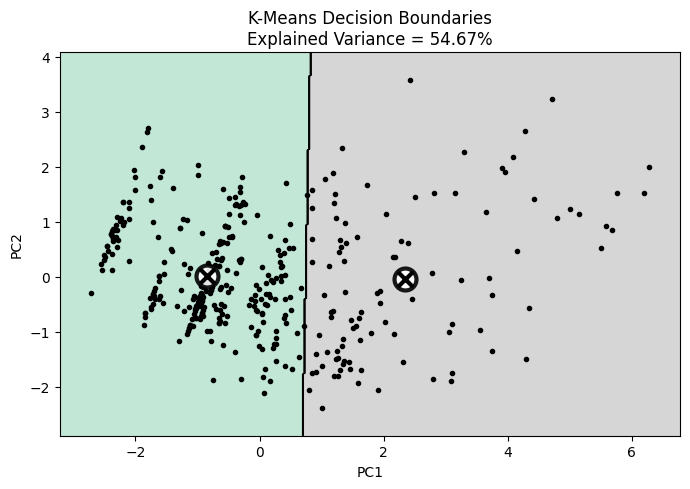

In [38]:
# PCA to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_A)

# Train KMeans on PCA space
kmeans_pca = KMeans(
    n_clusters=K,
    random_state=42
)

kmeans_pca.fit(X_pca)

plt.figure(figsize=(7,5))

plot_decision_boundaries(
    kmeans_pca,
    X_pca
)

plt.title(
    f"K-Means Decision Boundaries\n"
    f"Explained Variance = {pca.explained_variance_ratio_.sum()*100:.2f}%"
)

plt.tight_layout()
plt.show()

### 5) External Evaluation

#### - Contingency table / heatmap

In [39]:
def external_validation(results, y, target_name="Recurred"):
    df = results.copy()

    df[target_name] = y

    comparison = (
        pd.crosstab(
            df["Cluster"],
            df[target_name],
            normalize="index"
        )
    )

    comparison_counts = (
        pd.crosstab(
            df["Cluster"],
            df[target_name]
        )
    )

    return comparison, comparison_counts

In [40]:
external_results = {}

for key, rsl in results.items():

    comparison_ratio, comparison_count = external_validation(rsl, y)

    external_results[key] = {
        "ratio": comparison_ratio,
        "count": comparison_count
    }

In [41]:
def plot_external_validation(algo):

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for col, feature_set in enumerate(["A", "B"]):

        key = f"{algo}_{feature_set}"

        # -------------------------
        # Heatmap (Top Row)
        # -------------------------
        sns.heatmap(
            external_results[key]["ratio"],
            annot=True,
            fmt=".2f",
            cmap="PuBu",
            ax=axes[0, col]
        )

        axes[0, col].set_title(f"{algo} - Feature Set {feature_set}")
        axes[0, col].set_xlabel("Recurred")
        axes[0, col].set_ylabel("Cluster")

        # -------------------------
        # Stacked Bar (Bottom Row)
        # -------------------------
        external_results[key]["ratio"].plot(
            kind="bar",
            stacked=True,
            ax=axes[1, col],
            colormap="Set1"
        )

        axes[1, col].set_title(f"{algo} - Feature Set {feature_set}")
        axes[1, col].grid(alpha=0.5)
        axes[1, col].set_xlabel("Cluster")
        axes[1, col].set_ylabel("Proportion")
        axes[1, col].legend(title="Recurred")

    plt.tight_layout()
    plt.show()

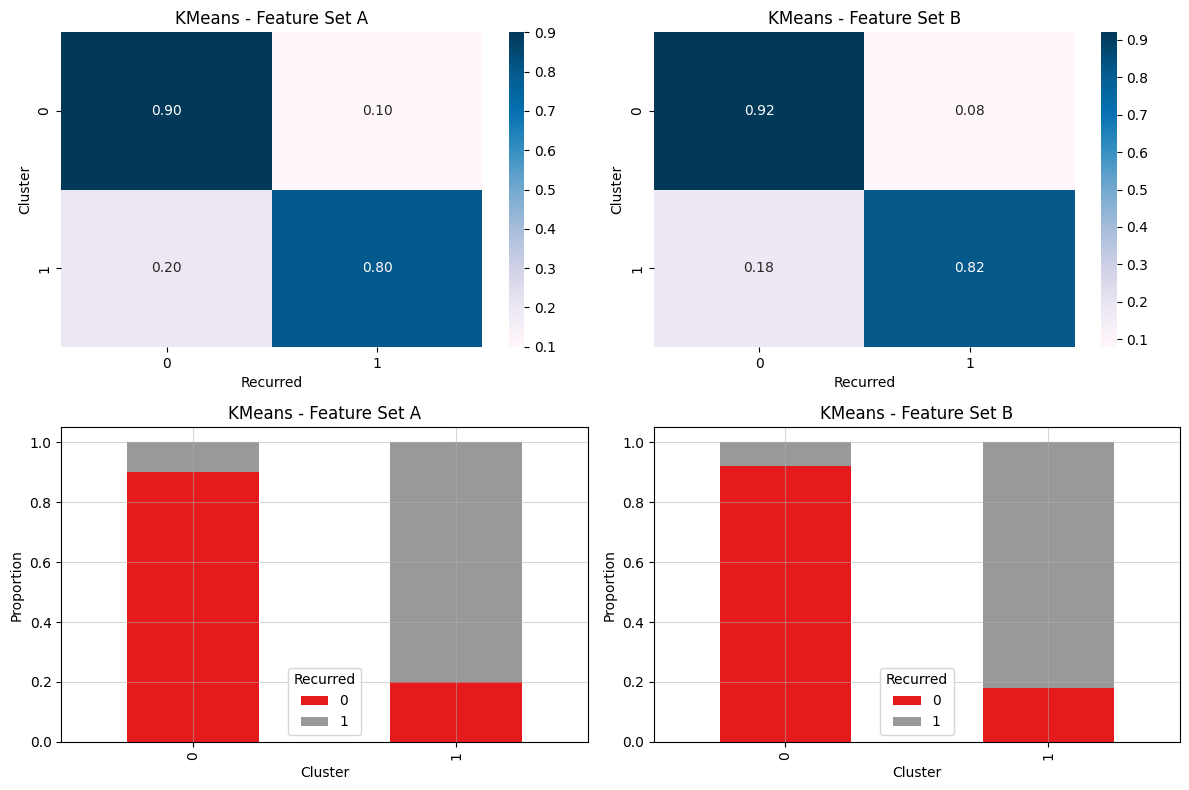

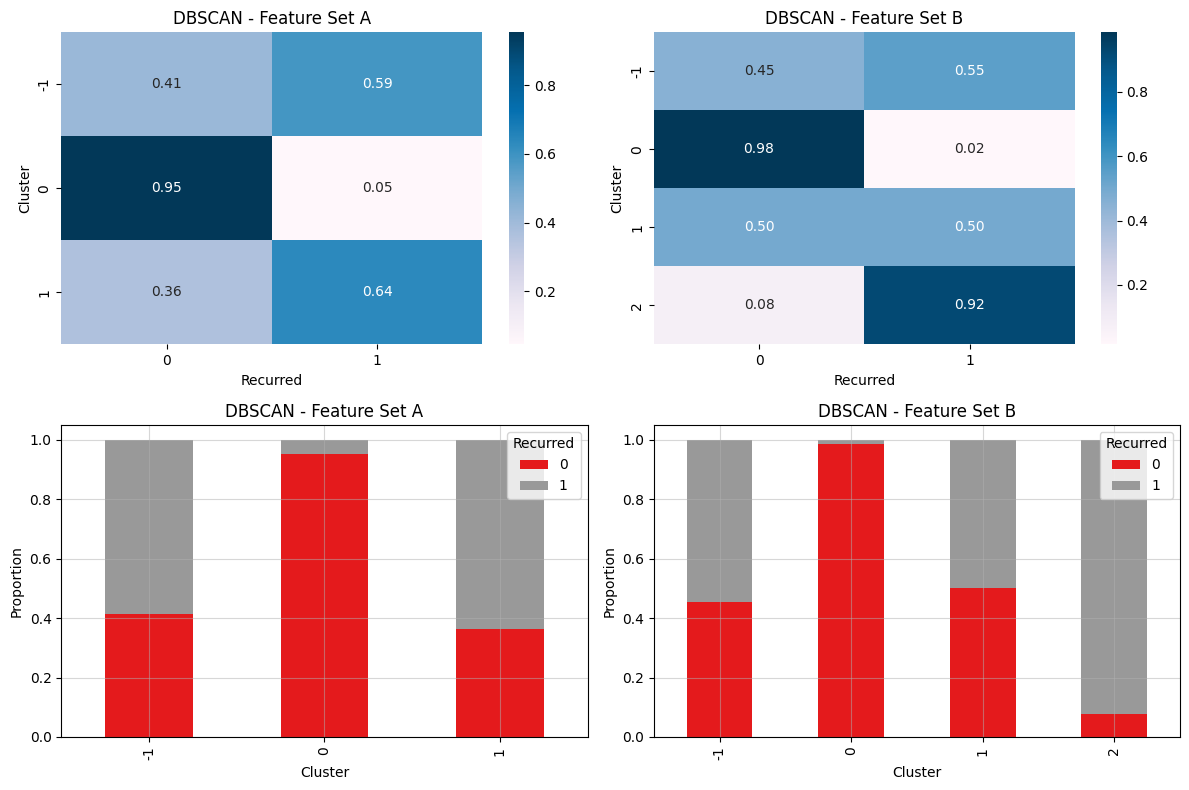

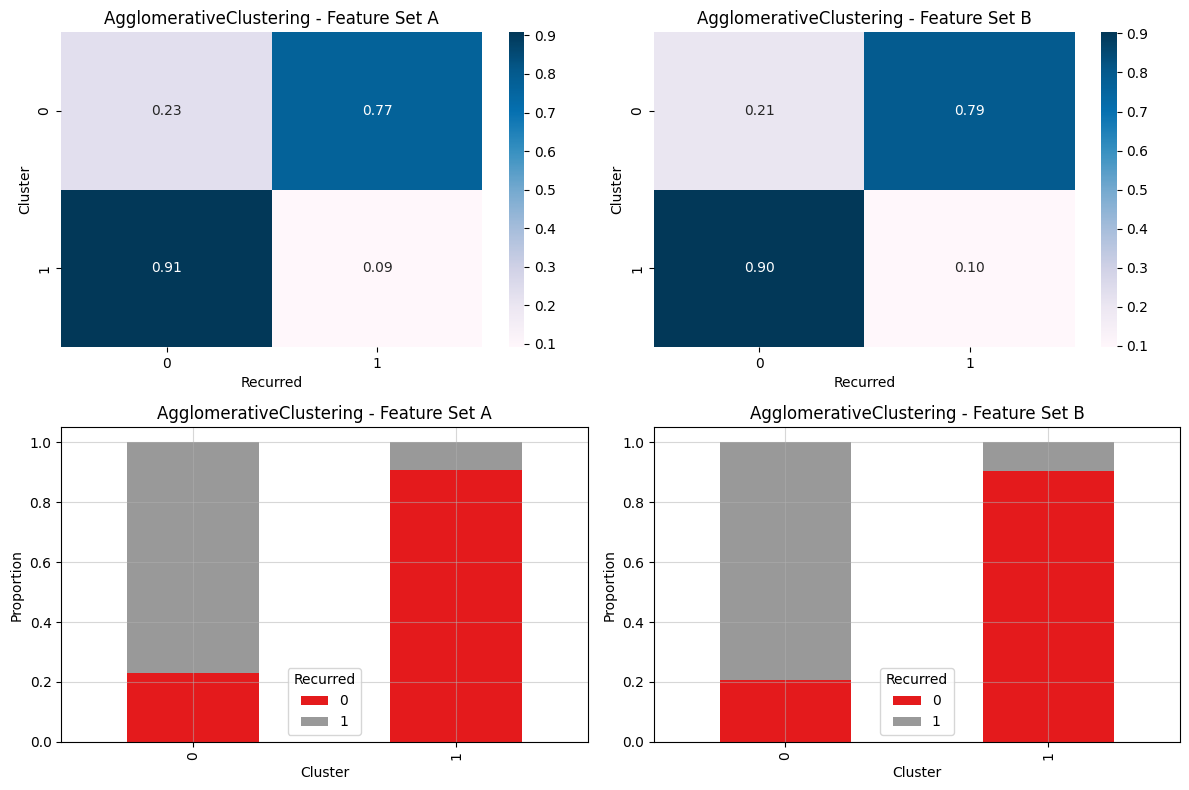

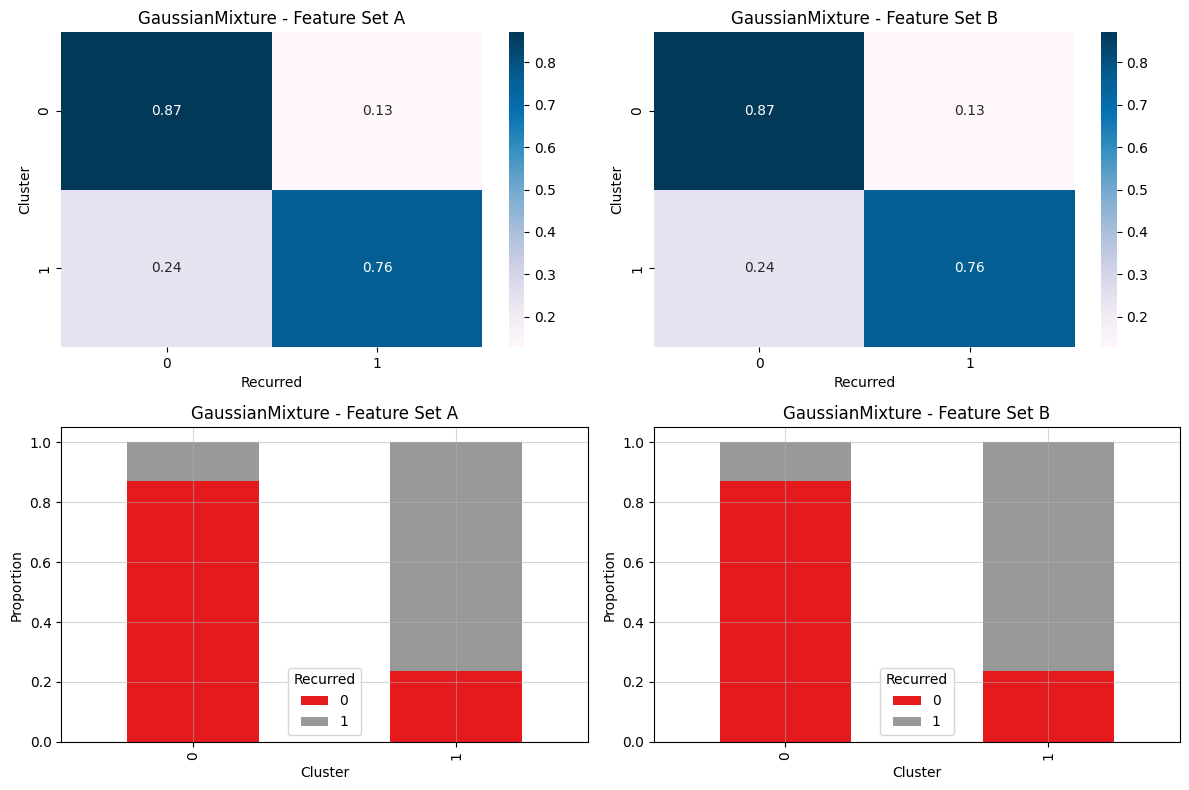

In [42]:
plot_external_validation("KMeans")
plot_external_validation("DBSCAN")
plot_external_validation("AgglomerativeClustering")
plot_external_validation("GaussianMixture")

### 6) Quantitative external evaluation

#### - Adjusted Rand Index (ARI) & Normalized Mutual Information (NMI)
- **ARI Range**
    - 1.0 → Perfect agreement
    - 0 → Random agreement
    - <0 → Worse than random (rare)

- **NMI Range**
    - 0 → No shared information
    - 1 → Perfect correspondence

In [43]:
def external_evaluation(results_dict, y_true):

    y_true = np.ravel(y_true)

    external_results = []

    for key, df in results_dict.items():

        clusters = df["Cluster"]

        ari = adjusted_rand_score(y_true, clusters)
        nmi = normalized_mutual_info_score(y_true, clusters)

        algorithm, feature_set = key.split("_")

        external_results.append({
            "Algorithm": algorithm,
            "Feature Set": feature_set,
            "ARI": ari,
            "NMI": nmi
        })

    return pd.DataFrame(external_results)

In [44]:
external_df = external_evaluation(results, y)
external_df

,Algorithm,Feature Set,ARI,NMI
0,KMeans,A,0.538504,0.384696
1,KMeans,B,0.599363,0.445904
2,DBSCAN,A,0.364718,0.266865
3,DBSCAN,B,0.329037,0.315957
4,AgglomerativeClustering,A,0.525651,0.374288
5,AgglomerativeClustering,B,0.539378,0.385626
6,GaussianMixture,A,0.447684,0.299517
7,GaussianMixture,B,0.447684,0.299517


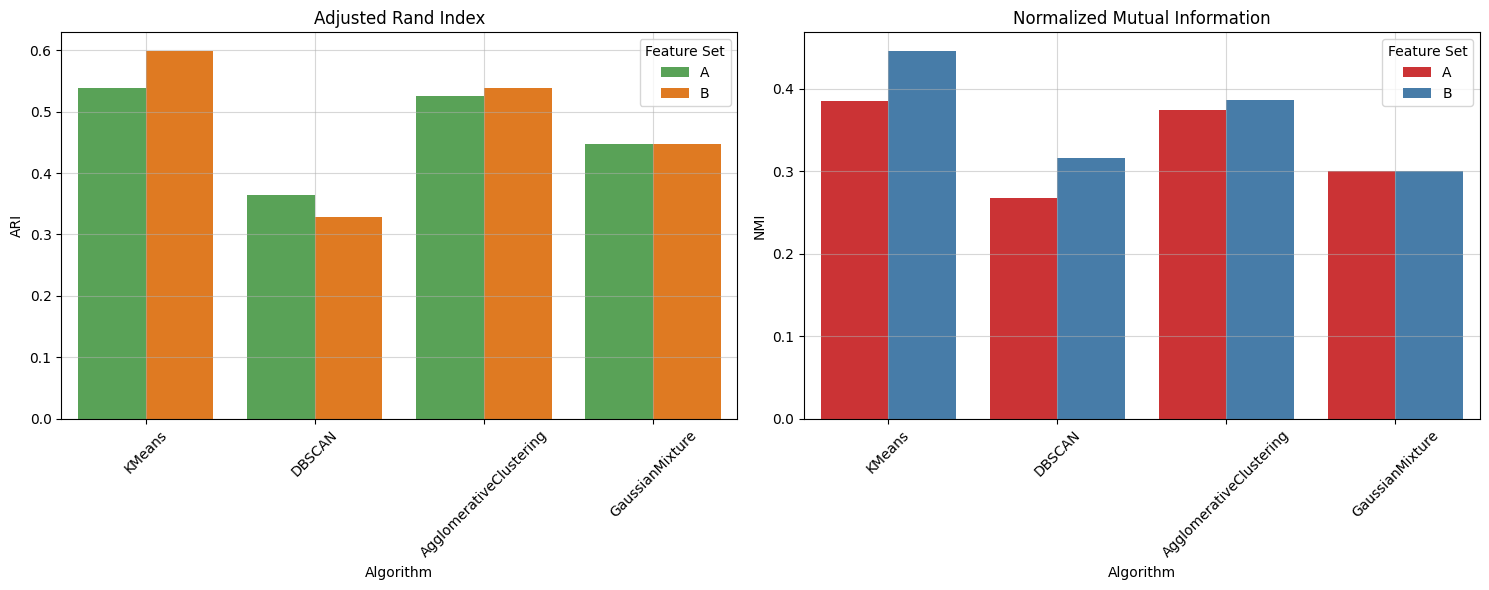

In [45]:
def plot_q_ext_eval(external_df):
    fig, axes = plt.subplots(1, 2, figsize=(15,6))

    sns.barplot(
        data=external_df,
        x="Algorithm",
        y="ARI",
        hue="Feature Set",
        ax=axes[0],
        palette=["#4daf4a", "#ff7802"]
    )

    axes[0].set_title("Adjusted Rand Index")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(alpha=0.5)

    sns.barplot(
        data=external_df,
        x="Algorithm",
        y="NMI",
        hue="Feature Set",
        ax=axes[1],
        palette=["#e41a1c", "#377eb8"]
    )

    axes[1].set_title("Normalized Mutual Information")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(alpha=0.5)

    plt.tight_layout()
    plt.show()


plot_q_ext_eval(external_df)

> This notebook demonstrated a complete unsupervised learning workflow for discovering latent patient subgroups in a thyroid cancer dataset. Multiple clustering algorithms and preprocessing pipelines were evaluated using internal validation metrics, visualization techniques, and external clinical validation. Among the evaluated methods, K-Means on Feature Set B achieved the strongest overall performance, producing compact, well-separated clusters that also exhibited meaningful agreement with recurrence status, despite never using recurrence labels during training. Examination of cluster characteristics further suggested that the discovered groups correspond to clinically interpretable patient phenotypes, differing in tumor stage, nodal involvement, multifocality, smoking history, and recurrence risk. These findings indicate that unsupervised learning can reveal clinically meaningful patient subgroups and can serve as a valuable exploratory tool for biomedical research, hypothesis generation, and patient stratification.